# **IBL brain-wide map dataset**

## **Overview**

### **The brain-wide map dataset**

The International Brain Laboratory (IBL) Brainwide Map project set out to map neural activity across the entire mouse brain at single-spike, cellular resolution during a standardized decision-making task. The resulting dataset has been made publicly available.

The dataset includes:


* Data collected across **12 laboratories**

* Recordings from **139 mice**

* A total of **459 behavioral sessions**

* **699 Neuropixels probe insertions**

* Coverage of **281 brain regions**

* **621,733 recorded neurons**, including

* **75,708 good neurons**


![](https://ibl-brain-wide-map-public.s3.us-east-1.amazonaws.com/sample_data/Neuromatch/figures/bwm_recordings.png)



### **Recording Plan**

Neural activity was recorded using Neuropixels probes, targeted according to a standardized grid system with insertion sites spaced 500 µm apart.

The recording system aimed to:
* Achieve uniform coverage across the brain

* Prioritize regions with known anatomical connectivity (e.g., the cerebellum and medulla were sampled from the right hemisphere)

* Replicate each recording site in at least two independent laboratories

* Evaluate the reproducibility of neural activity across subjects and experimental sites (via the "repeated site")

* Investigate bilateral and interhemispheric interactions (via the "bilateral sites")

![](https://ibl-brain-wide-map-public.s3.us-east-1.amazonaws.com/sample_data/Neuromatch/figures/bwm_plan.png)


### **Decision making task**

In the IBL decision making task a visual stimulus appears at the edge of the screen and mice must bring the stimulus to the screen centre by moving a wheel with their front two paws. If they successfully bring the stimulus to the screen centre, they receive a reward of sugar water ; if however they move the wheel in the wrong direction until the stimulus reaches beyond the screen edge, a white noise tone is played. To initiate a trial, the mouse must hold the wheel still for a continuous period between 0.4-0.7s ; they are then alerted of the start of the trial by the simultaneous presentation of the stimulus on the screen and a go cue tone. Mice have a maximum of 60s to make a decision before the trial times out and a white noise tone is played.

Varying contrasts of visual stimulus are shown throughout the session (100%, 25%, 12.5%, 6.25% and 0%). The probability of the stimulus appearing on the left or the right changes between blocks of trials. During 0% contrast trials (where no stimulus appears on the screen but a wheel response is required), the mice can use the inferred block structure to guide their decision.


![](https://ibl-brain-wide-map-public.s3.us-east-1.amazonaws.com/sample_data/Neuromatch/figures/task.png)


### **Accessing the data**
For the purposes of this course, we have precomputed task-aligned peri-stimulus time histograms (PSTHs) for all good clusters in the dataset. This allows you to quickly begin working with the data using a simplified and accessible format. The tutorial below is based on this preprocessed data.

To access the full dataset, including raw electrophysiology (action potential and LFP bands), spike sorting output, wheel movement, video recordings, and pose estimation data please refer to this [this introductary notebook](https://colab.research.google.com/drive/1_1qfa-DLDbezyFXguFOnJJWF5aJ5AH0i#scrollTo=-TJR7XEgtBxS) and [this tutorial](https://colab.research.google.com/drive/1y3sRI1wC7qbWqN6skvulzPOp6xw8tLm7#scrollTo=hRZA78AoaBIC).



> *All data are made available under the CC BY 4.0 license.*

EXP

The Peri-Stimulus Time Histogram (PSTH) is a common way to visualize how a neuron's firing rate changes in response to a specific event, like the presentation of a stimulus or the initiation of a movement.

Here's a simple breakdown:

Peri-Stimulus: This means "around the stimulus" or "around the event." You define a specific event (e.g., when a light flashes, or when an animal presses a lever) as your reference point.  
Time Histogram: This refers to creating a histogram of when a neuron fires (spikes) relative to that reference event. You collect data from many repetitions of the same event and then count how many times the neuron fired in small time bins (e.g., every 10 milliseconds) before and after the event.  

Essentially, a PSTH tells you:

When a neuron tends to fire more or less often in relation to a particular event.  
How consistently it responds to that event across multiple trials.  

It helps researchers understand the temporal dynamics of neural activity and how it's linked to sensory input, motor output, or cognitive processes.

## **1. Installation and setup**

The code blocks in this section install and import required packages. We also define a set of utility functions that will be used to download and load data throughout the rest of the tutorial. **Make sure these cells are run before continuing onto the next sections.**

### **Install dependencies**

In [ ]:
! pip install ONE-api --quiet
! pip install ibllib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.6/442.6 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.1/226.1

### **Setup ONE**

In [ ]:
# When running in jupyter set number of threads to 1
import os
os.environ.setdefault('ONE_HTTP_DL_THREADS', '1')

from one.api import ONE
ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
one = ONE(password='international')

Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"


### **Define imports**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import pandas as pd
from scipy import sparse
import numpy as np
from one.remote.aws import s3_download_file
import zipfile
import tqdm
import scipy.stats as stats
from iblutil.util import Bunch
from scipy.ndimage import gaussian_filter1d

# Machine learning tools for dimensionality reduction (Principal Component Analysis), classification (Logistic Regression), and splitting data for training and testing models
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# This is to view dataframe interactively in Google colab
if 'google.colab' in sys.modules:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()

# This is to style figures
if sys.version_info >= (3, 10):
    from ibl_style.style import figure_style
    figure_style()

### **Define loading utility functions**

stimOn: This event marks the exact moment the visual stimulus appears on the screen in front of the mouse. Data aligned to stimOn is used to study how neurons respond to the onset of a visual cue.

firstMove: This event refers to when the mouse initiates its first wheel turn, moving the stimulus past a certain threshold. Data aligned to firstMove is useful for analyzing neural activity related to motor initiation and decision-making leading up to a physical response.

feedback: This event indicates the time when the mouse receives feedback on its choice, either a reward (sugar water) or a white noise tone for an incorrect response. Data aligned to feedback allows researchers to investigate neural processing related to outcomes and reinforcement learning.

In [ ]:
def download_data(event):
  assert event in ['firstMove', 'stimOn', 'feedback'], 'event must be one of "firstMove", "stimOn" or "feedback'

  # Dataset name
  fname = f'data_{event}.zip'
  # Remote location of data
  s3_data_path = f'sample_data/Neuromatch/{fname}'
  # Local location to download data to
  save_path = one.cache_dir.joinpath('Neuromatch', fname)
  save_path.parent.mkdir(exist_ok=True, parents=True)

  # Download file
  file = s3_download_file(s3_data_path, save_path)
  # Unzip content
  with zipfile.ZipFile(file, 'r') as zip_ref:
    zip_ref.extractall(save_path.parent)


def get_data_path(event):
  return one.cache_dir.joinpath('Neuromatch', f'data_{event}')


def load_metadata(event):
  metadata = Bunch()
  data_path = get_data_path(event)
  metadata['clusters'] = pd.read_parquet(data_path.joinpath('clusters.pqt'))
  metadata['trials'] = pd.read_parquet(data_path.joinpath('trials.pqt'))
  metadata['sessions'] = pd.read_parquet(data_path.joinpath('sessions.pqt'))
  metadata['times'] = np.load(data_path.joinpath('t.npy'))
  metadata['nbins'] = metadata['times'].size
  metadata['dt'] = np.round(np.median(np.diff(metadata['times'])), 2)
  metadata['data_path'] = data_path

  return metadata


def load_times(data_path):
  return np.load(data_path.joinpath('t.npy'))


def load_psth(data_path, pid, nbins=150):
    psth = sparse.load_npz(data_path.joinpath(f'{pid}.npz')).toarray()
    psth = psth.reshape(psth.shape[0], -1, nbins)
    return psth

The selected code cell defines several utility functions primarily for downloading, loading, and managing data from the International Brain Laboratory (IBL) brain-wide map dataset. These functions are crucial for accessing the pre-processed PSTH data aligned to specific task events.

Here's a breakdown of each function:

download_data(event): This function is responsible for downloading the zipped data files for a specified event. It takes an event string (which must be one of 'firstMove', 'stimOn', or 'feedback') as input. It constructs the file name and remote S3 path, then downloads the .zip file to a local cache directory and extracts its contents.

get_data_path(event): This helper function simply returns the local file path to the directory where the data for a given event is stored after being downloaded and unzipped. It uses the one.cache_dir for consistent storage.

load_metadata(event): This is a core function for loading various metadata tables associated with an event. It uses get_data_path to locate the data and then reads several Parquet files (clusters.pqt, trials.pqt, sessions.pqt) and a NumPy array (t.npy). It organizes this information into a Bunch object (a dictionary-like object that allows access to keys as attributes), also calculating nbins (number of time bins) and dt (time step).

load_times(data_path): This is a more specific loader that reads just the t.npy file from a given data_path, which contains the time points for the peri-stimulus time histogram (PSTH).

load_psth(data_path, pid, nbins=150): This function loads the actual PSTH data for a specific probe insertion. It takes the data_path, the pid (probe insertion ID), and the number of time nbins as input. It loads a sparse NumPy array (.npz file) corresponding to the pid and reshapes it into a 3D array of n_trials x n_clusters x n_time_bins.

### **Define processing utility functions** <a name="Utility-functions"></a>

In [ ]:
def split_trials_by_variable(trials, split='contrast'):
  trials = trials.set_index('psth_index')
  if split == 'contrast':
    trials['contrast'] = np.nansum([trials['contrastLeft'], trials['contrastRight']], axis=0) * 100
    grp = trials.groupby('contrast')
  elif split == 'signed contrast':
    trials['signedContrast'] = np.nansum([-1 * trials['contrastLeft'], trials['contrastRight']], axis=0) * 100
    grp = trials.groupby('signedContrast')
  elif split == 'stimulus':
    trials['stimulus'] = 'right'
    trials.loc[trials['contrastRight'].isna(), 'stimulus'] = 'left'
    grp = trials.groupby('stimulus')
  elif split == 'choice':
    grp = trials.groupby('choice')
  elif split == 'block':
    grp = trials.groupby('probabilityLeft')
  else:
    raise NotImplementedError('split must be one of "contrast", "signed contrast", "stimulus", "choice" or "block"')

  return grp.groups


def get_avg_psth_for_insertion(pid, meta, reg=None, uuids=None, split=None):

  df = meta.clusters[meta.clusters['pid'] == pid]
  df = df[['acronym', 'pid', 'uuids', 'cluster_id', 'psth_index']]
  sp = load_psth(meta.data_path, pid, nbins=meta.nbins)

  if reg is not None:
    in_reg = df['acronym'] == reg
    sp = sp[:, in_reg.values, :]
    df = df[in_reg].reset_index(drop=True)

  if uuids is not None:
    in_uuid = df['uuids'].isin(uuids)
    sp = sp[:, in_uuid.values, :]
    df = df[in_uuid].reset_index(drop=True)

  if split is None:
    psth = sp.mean(axis=0) / meta['dt']
  else:
    psth = dict()
    eid = meta.sessions[meta.sessions['pid'] == pid].iloc[0]['eid']
    trials = meta.trials[meta.trials['eid'] == eid].reset_index(drop=True)
    grps = split_trials_by_variable(trials, split=split)

    for key, vals in grps.items():
      psth[key] = sp[vals, :, :].mean(axis=0)

  return psth, df

def get_avg_psth_for_region(reg, meta, split=None):
  clusters = meta.clusters[meta.clusters['acronym'] == reg]
  pids = clusters['pid'].unique()
  all_df = []
  all_psth = []
  for pid in pids:
    psth, df = get_avg_psth_for_insertion(pid, meta, reg=reg, split=split)
    all_df.append(df)
    all_psth.append(psth)

  all_df = pd.concat(all_df).reset_index(drop=True)
  if split is None:
    all_psth = np.concatenate(all_psth)
  else:
    all_psth = {key: np.concatenate([d[key] for d in all_psth if key in d.keys()])
    for key in all_psth[0]}


  return all_psth, all_df


def get_avg_psth_for_clusters(uuids, meta, split=None):
  clusters = meta.clusters[meta.clusters['uuids'].isin(uuids)]
  pids = clusters['pid'].unique()
  all_df = []
  all_psth = []
  for pid in pids:
    psth, df = get_avg_psth_for_insertion(pid, meta, uuids=uuids, split=split)
    all_df.append(df)
    all_psth.append(psth)

  all_df = pd.concat(all_df).reset_index(drop=True)
  if split is None:
    all_psth = np.concatenate(all_psth)
  else:
    all_psth = {key: np.concatenate([d[key] for d in all_psth if key in d.keys()])
    for key in all_psth[0]}

  return all_psth, all_df



def get_psth_for_insertion(pid, meta, reg=None, uuids=None):

  df = meta.clusters[meta.clusters['pid'] == pid]
  df = df[['acronym', 'pid', 'uuids', 'cluster_id', 'psth_index']]
  sp = load_psth(meta.data_path, pid, nbins=meta.nbins)

  if reg is not None:
    in_reg = df['acronym'] == reg
    sp = sp[:, in_reg.values, :]
    df = df[in_reg].reset_index(drop=True)

  if uuids is not None:
    in_uuid = df['uuids'].isin(uuids)
    sp = sp[:, in_uuid.values, :]
    df = df[in_uuid].reset_index(drop=True)


  eid = meta.sessions[meta.sessions['pid'] == pid].iloc[0]['eid']
  trials = meta.trials[meta.trials['eid'] == eid].reset_index(drop=True)
  psth = sp / meta['dt']

  return psth, df, trials


def get_psth_for_region(reg, meta):

  clusters = meta.clusters[meta.clusters['acronym'] == reg]
  pids = clusters['pid'].unique()
  all_clust = []
  all_psth = []
  all_trials = []
  for pid in pids:
    psth, clust, trials = get_psth_for_insertion(pid, meta, reg=reg)
    all_clust.append(clust)
    all_psth.append(psth)
    all_trials.append(trials)

  return all_psth, all_clust, all_trials


def get_psth_for_clusters(uuids, meta):

  clusters = meta.clusters[meta.clusters['uuids'].isin(uuids)]
  pids = clusters['pid'].unique()
  all_clust = []
  all_psth = []
  all_trials = []
  for pid in pids:
    psth, clust, trials = get_psth_for_insertion(pid, meta, uuids=uuids)
    all_clust.append(clust)
    all_psth.append(psth)
    all_trials.append(trials)

  return all_psth, all_clust, all_trials

The selected code cell contains a set of crucial utility functions for processing and retrieving peri-stimulus time histogram (PSTH) data from the International Brain Laboratory (IBL) dataset. These functions allow for flexible ways to access neural activity aligned to specific task events, either aggregated or at the trial level, and often categorized by different experimental variables. Let's go through each one:

split_trials_by_variable(trials, split='contrast'):

Purpose: This function takes a DataFrame of trial metadata and groups it by a specified variable. This is useful for analyzing how neural activity differs across various trial conditions (e.g., different contrasts, stimulus sides, or choices).
Parameters:
trials (pd.DataFrame): A DataFrame containing trial metadata.
split (str, optional): The variable by which to group the trials. It can be 'contrast', 'signed contrast', 'stimulus', 'choice', or 'block'. Defaults to 'contrast'.
Returns: A dictionary where keys are the unique values of the split variable (e.g., contrast levels) and values are lists of psth_index values corresponding to trials belonging to that group.
get_avg_psth_for_insertion(pid, meta, reg=None, uuids=None, split=None):

Purpose: Loads and computes trial-averaged PSTHs for all clusters within a specific probe insertion (pid). It can also filter by brain region or specific cluster UUIDs and split the data by trial variables.
Parameters:
pid (str): The unique probe insertion ID.
meta (Bunch): A Bunch object containing metadata (clusters, trials, sessions, times).
reg (str, optional): An acronym for a brain region to filter clusters. Defaults to None.
uuids (list, optional): A list of cluster UUIDs to filter clusters. Defaults to None.
split (str, optional): The variable by which to split the trials for averaging (uses split_trials_by_variable). If None, returns a single average PSTH across all trials.
Returns:
If split is None: A 2D NumPy array of shape n_clusters x n_time_bins representing the trial-averaged PSTH, converted to firing rate.
If split is specified: A dictionary where keys are the split categories and values are 2D NumPy arrays (avg PSTHs) for each category.
A pandas DataFrame containing metadata for the selected clusters.
get_avg_psth_for_region(reg, meta, split=None):

Purpose: Aggregates and averages PSTH data across all probe insertions that recorded from a specified brain region.
Parameters:
reg (str): The acronym for the brain region.
meta (Bunch): Metadata object.
split (str, optional): Trial splitting variable. Defaults to None.
Returns:
If split is None: A 2D NumPy array of shape n_total_clusters_in_region x n_time_bins.
If split is specified: A dictionary with split categories and aggregated PSTH arrays.
A pandas DataFrame with metadata for all clusters in the specified region.
get_avg_psth_for_clusters(uuids, meta, split=None):

Purpose: Similar to get_avg_psth_for_region, but aggregates and averages PSTH data for a specific list of cluster UUIDs, potentially spanning multiple probe insertions and regions.
Parameters:
uuids (list): A list of unique cluster identifiers.
meta (Bunch): Metadata object.
split (str, optional): Trial splitting variable. Defaults to None.
Returns:
If split is None: A 2D NumPy array of shape n_specified_clusters x n_time_bins.
If split is specified: A dictionary with split categories and aggregated PSTH arrays.
A pandas DataFrame with metadata for the specified clusters.
get_psth_for_insertion(pid, meta, reg=None, uuids=None):

Purpose: Loads raw (non-averaged) PSTH data at the individual trial level for a given probe insertion.
Parameters: Similar to get_avg_psth_for_insertion for pid, meta, reg, and uuids.
Returns:
A 3D NumPy array of shape n_trials x n_clusters x n_time_bins containing the PSTH data for each trial, converted to firing rate.
A pandas DataFrame with metadata for the selected clusters.
A pandas DataFrame with metadata for the trials associated with that insertion.
get_psth_for_region(reg, meta):

Purpose: Loads raw (non-averaged) PSTH data at the individual trial level for all clusters within a specified brain region, across all relevant insertions.  
Parameters:  
reg (str): The acronym for the brain region.  
meta (Bunch): Metadata object.  
Returns: Three lists: one for PSTH arrays (each element is a 3D array for an insertion), one for cluster DataFrames, and one for trial DataFrames. Each list element corresponds to a probe insertion.
get_psth_for_clusters(uuids, meta):

Purpose: Loads raw (non-averaged) PSTH data at the individual trial level for a given list of cluster UUIDs.
Parameters:
uuids (list): A list of unique cluster identifiers.
meta (Bunch): Metadata object.
Returns: Three lists: one for PSTH arrays, one for cluster DataFrames, and one for trial DataFrames. Each list element corresponds to a probe insertion from which the clusters were recorded.
These functions together provide a comprehensive toolkit for researchers to explore and analyze neural activity within the IBL brain-wide map dataset, facilitating investigations from single-unit responses to region-wide population dynamics and decoding studies.

## **2. Data Access**
In this section we will show how to **download and load the preprocessed data** and walk through the **structure and content of the data** to help you become familiar with its organisation and key components.

### **Data Format**
To facilitate analysis, we have prepared three ZIP files containing data aligned to different key task events:

* `data_stimOn.zip` — aligned to **stimulus onset**, the moment the visual stimulus appears on the screen

* `data_firstMove.zip` — aligned to the **first movement**, when the mouse initiates a wheel turn that moves the stimulus past threshold

* `data_feedback.zip` — aligned to **feedback time**, when the mouse receives feedback based on its choice


Each ZIP archive contains the following files:

* `clusters.pqt` — metadata for each recorded cluster (e.g. brain region)

* `trials.pqt` — behavioral trial data (e.g. stimulus, choice, contrast)

* `sessions.pqt` — metadata for each recording session (e.g. subject, lab)

* `t.npy` — timepoints for the peri-stimulus time histogram (PSTH); spans from -0.5 s to +1.0 s around the event in 10 ms steps

* `{pid}.npz` — PSTH data for each individual probe insertion, labeled by its unique probe ID (pid)


🔍 What are eid and pid?

Throughout the dataset and code, you will encounter two key identifiers:

* `eid` — the experiment/session ID, uniquely identifying each behavioral session

* `pid` — the probe insertion ID, uniquely identifying each Neuropixels insertion

A single eid may be associated with multiple pids, since several probes can be recorded from during the same session.

### **Downloading the data**

The data for a given aligned event can be downloaded in the following way.

In [ ]:
download_data('stimOn')

(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/Neuromatch/data_stimOn.zip: 100%|██████████| 810M/810M [00:08<00:00, 90.8MB/s]


### **Loading metadata**
We can load all of the metadata (cluster, trial, session and timestamps data) in the following way.

In [ ]:
meta = load_metadata('stimOn')
print(f'Meta data contains the following keys: {list(meta.keys())}')

Meta data contains the following keys: ['clusters', 'trials', 'sessions', 'times', 'nbins', 'dt', 'data_path']


**Clusters**

The `clusters.pqt` table contains metadata for each cluster in the dataset. Key columns include:

* `acronym`: Brain region label for the cluster, based on the Allen CCF annotation

* `pid`: Probe insertion ID indicating which Neuropixels probe the cluster was recorded from

* `psth_index`: Index into the PSTH array for the corresponding pid (clusters are along the first dimension)

* `cluster_id`: Cluster identifier used for linking to the IBL visualization website (unique within a pid)

* `uuids`: Unique identifier for each cluster






psth_index: Index into the PSTH array.  
uuids: Unique identifier for each cluster.  
cluster_id: Cluster identifier (unique within a pid).  
firing_rate: Firing rate of the cluster.  
x, y, z: Spatial coordinates of the cluster.  
atlas_id_allen: Allen Brain Atlas ID.  
pid: Probe insertion ID.  
acronym: Brain region label for the cluster.  
acronym_allen: Allen Brain Atlas acronym for the region.

In [ ]:
meta.clusters.shape

(75708, 11)

In [ ]:
meta.clusters

,psth_index,uuids,cluster_id,firing_rate,x,y,z,atlas_id_allen,pid,acronym,acronym_allen
0,0,c7d051dc-1358-422d-9eab-ca13c6b6be1b,2,2.831652,-0.002289,-0.002537,-0.003595,549,56f2a378-78d2-4132-b3c8-8c1ba82be598,root,TH
1,1,38bc27f2-7301-405a-a870-54e0a7b06a26,15,6.941674,-0.002289,-0.002533,-0.003576,549,56f2a378-78d2-4132-b3c8-8c1ba82be598,root,TH
2,2,1c4e5e11-ca9d-441a-bb8f-4b56dcc95054,22,2.702620,-0.002289,-0.002528,-0.003556,549,56f2a378-78d2-4132-b3c8-8c1ba82be598,root,TH
3,3,b48a90ed-84f4-424d-87ae-92c22a423777,23,5.210307,-0.002289,-0.002528,-0.003556,549,56f2a378-78d2-4132-b3c8-8c1ba82be598,root,TH
4,4,38a812b9-b374-46f8-ab14-3dd146411fc8,26,10.565215,-0.002289,-0.002528,-0.003556,549,56f2a378-78d2-4132-b3c8-8c1ba82be598,root,TH
...,...,...,...,...,...,...,...,...,...,...,...
75703,101,1ed6f713-96c5-4d33-a97f-45ad7f436ca7,950,9.926329,-0.001189,-0.000700,-0.003936,629,79f44ba1-c931-4346-82eb-f628a9374045,VAL,VAL
75704,102,1d7d0f85-2662-4844-99e2-173207669d41,951,13.529734,-0.001189,-0.000700,-0.003936,629,79f44ba1-c931-4346-82eb-f628a9374045,VAL,VAL
75705,103,7e5690d8-47d5-4e30-9c86-a3026c761900,961,7.518199,-0.001268,-0.000662,-0.003596,255,79f44ba1-c931-4346-82eb-f628a9374045,AV,AV
75706,104,94c77f09-d88c-4188-bcbb-7b6e26b26905,972,0.808297,-0.001866,-0.000671,-0.001482,478,79f44ba1-c931-4346-82eb-f628a9374045,SSp-ll,SSp-ll6a


In [ ]:
meta.clusters[0:100]

,psth_index,uuids,cluster_id,firing_rate,x,y,z,atlas_id_allen,pid,acronym,acronym_allen
0,0,c7d051dc-1358-422d-9eab-ca13c6b6be1b,2,2.831652,-0.002289,-0.002537,-0.003595,549,56f2a378-78d2-4132-b3c8-8c1ba82be598,root,TH
1,1,38bc27f2-7301-405a-a870-54e0a7b06a26,15,6.941674,-0.002289,-0.002533,-0.003576,549,56f2a378-78d2-4132-b3c8-8c1ba82be598,root,TH
2,2,1c4e5e11-ca9d-441a-bb8f-4b56dcc95054,22,2.702620,-0.002289,-0.002528,-0.003556,549,56f2a378-78d2-4132-b3c8-8c1ba82be598,root,TH
3,3,b48a90ed-84f4-424d-87ae-92c22a423777,23,5.210307,-0.002289,-0.002528,-0.003556,549,56f2a378-78d2-4132-b3c8-8c1ba82be598,root,TH
4,4,38a812b9-b374-46f8-ab14-3dd146411fc8,26,10.565215,-0.002289,-0.002528,-0.003556,549,56f2a378-78d2-4132-b3c8-8c1ba82be598,root,TH
...,...,...,...,...,...,...,...,...,...,...,...
95,19,e28cfb7c-0643-4473-9fef-3433911ec373,123,6.504648,-0.002971,-0.001782,-0.006251,334,47be9ae4-290f-46ab-b047-952bc3a1a509,BMA,BMAp
96,20,b3b657e3-f6b4-4c13-9b55-58e4f220fb64,125,3.412639,-0.002971,-0.001782,-0.006251,334,47be9ae4-290f-46ab-b047-952bc3a1a509,BMA,BMAp
97,21,4b5bf195-0527-445e-a879-dcffa8072131,127,1.272447,-0.002966,-0.001777,-0.006232,334,47be9ae4-290f-46ab-b047-952bc3a1a509,BMA,BMAp
98,22,f1984098-82db-437a-817d-6c0ef122af9b,130,7.866468,-0.002966,-0.001777,-0.006232,334,47be9ae4-290f-46ab-b047-952bc3a1a509,BMA,BMAp


In [ ]:
meta.clusters.columns

Index(['psth_index', 'uuids', 'cluster_id', 'firing_rate', 'x', 'y', 'z',
       'atlas_id_allen', 'pid', 'acronym', 'acronym_allen'],
      dtype='object')

**Trials**

The `trials.pqt` table contains metadata for each behavioral trial in the dataset. Key columns include:

* `eid`: Experiment/session ID indicating which session the trial belongs to

* `psth_index`: Index into the PSTH array for the corresponding pid (trials are along the first dimension)

* `probabilityLeft`: Probability that the visual stimulus would appear on the left side of the screen

* `feedbackType`: Indicates trial outcome, 1 for correct, -1 for incorrect

* `contrastLeft`: Contrast of the visual stimulus when presented on left; nan values indicate contrast was shown on right hand side of screen

* `contrastRight`: Contrast of the visual stimulus when presented on right; nan values indicate contrast was shown on left hand side of screen

* `choice`: Mouse's choice, 1 for clockwise wheel turn (typically indicating a rightward choice), -1 for anticlockwise turn (leftward choice)

* `block`: The block number number of the trial

* `block_trial_number`: The index of the trial relative to the most recent block switch (i.e., trial number within the current block)

In [ ]:
meta.trials.shape

(196503, 9)

In [ ]:
meta.trials

,eid,probabilityLeft,feedbackType,contrastLeft,contrastRight,choice,psth_index,block,block_trial_number
0,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,1.0,0.125,NaN,1.0,0,0,9
1,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,-1.0,NaN,0.250,1.0,1,0,12
2,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,-1.0,NaN,0.250,1.0,2,0,14
3,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,1.0,0.250,NaN,1.0,3,0,16
4,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,-1.0,NaN,0.125,1.0,4,0,19
...,...,...,...,...,...,...,...,...,...
196498,c7bd79c9-c47e-4ea5-aea3-74dda991b48e,0.2,1.0,NaN,0.125,-1.0,1084,23,11
196499,c7bd79c9-c47e-4ea5-aea3-74dda991b48e,0.2,1.0,NaN,0.125,-1.0,1085,23,14
196500,c7bd79c9-c47e-4ea5-aea3-74dda991b48e,0.2,-1.0,NaN,0.000,1.0,1086,23,17
196501,c7bd79c9-c47e-4ea5-aea3-74dda991b48e,0.2,1.0,NaN,0.000,-1.0,1087,23,18


In [ ]:
meta.trials[0:100]

,eid,probabilityLeft,feedbackType,contrastLeft,contrastRight,choice,psth_index,block,block_trial_number
0,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,1.0,0.125,NaN,1.0,0,0,9
1,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,-1.0,NaN,0.250,1.0,1,0,12
2,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,-1.0,NaN,0.250,1.0,2,0,14
3,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,1.0,0.250,NaN,1.0,3,0,16
4,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,-1.0,NaN,0.125,1.0,4,0,19
...,...,...,...,...,...,...,...,...,...
95,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.2,1.0,NaN,0.000,-1.0,95,2,18
96,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.2,1.0,NaN,0.250,-1.0,96,2,19
97,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.2,1.0,NaN,0.125,-1.0,97,2,20
98,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.2,1.0,NaN,0.250,-1.0,98,2,21


In [ ]:
meta.trials.columns

Index(['eid', 'probabilityLeft', 'feedbackType', 'contrastLeft',
       'contrastRight', 'choice', 'psth_index', 'block', 'block_trial_number'],
      dtype='object')

In [ ]:
meta.trials.feedbackType.value_counts()

,count
feedbackType,
1.0,168086
-1.0,28417


In [ ]:
meta.trials.choice.value_counts()

,count
choice,
1.0,99796
-1.0,96707


**Sessions**

The `sessions.pqt` table contains metadata for each recording session and serves as a link between the clusters and trials tables via the `eid` and `pid` columns.

Key columns include:

* `lab`: Name of the lab where the recording was performed

* `subject`: Identifier for the mouse used in the session

* `eid`: Experiment/session ID; multiple probe insertions (pids) with the same eid were recorded simultaneously during a single behavioral session

* `pid`: Probe insertion ID corresponding to a specific Neuropixels probe used during the session




In [ ]:
meta.sessions.shape

(699, 7)

In [ ]:
meta.sessions

,pid,eid,probe_name,session_number,date,subject,lab
0,56f2a378-78d2-4132-b3c8-8c1ba82be598,6713a4a7-faed-4df2-acab-ee4e63326f8d,probe00,1,2020-02-18,NYU-11,angelakilab
1,47be9ae4-290f-46ab-b047-952bc3a1a509,56956777-dca5-468c-87cb-78150432cc57,probe01,1,2020-02-21,NYU-11,angelakilab
2,6be21156-33b0-4f70-9a0f-65b3e3cd6d4a,56956777-dca5-468c-87cb-78150432cc57,probe00,1,2020-02-21,NYU-11,angelakilab
3,8dfb86c8-d45c-46c4-90ec-33078014d434,4364a246-f8d7-4ce7-ba23-a098104b96e4,probe01,1,2020-01-20,NYU-12,angelakilab
4,c893c0a3-5597-49cf-baa1-60efdfdef542,b182b754-3c3e-4942-8144-6ee790926b58,probe01,1,2020-01-21,NYU-12,angelakilab
...,...,...,...,...,...,...,...
694,8bf0f1a4-0d8c-4df3-a99e-f7c81c809652,993c7024-0abc-4028-ad30-d397ad55b084,probe01,1,2020-09-16,CSH_ZAD_029,zadorlab
695,5d570bf6-a4c6-4bf1-a14b-2c878c84ef0e,fece187f-b47f-4870-a1d6-619afe942a7d,probe01,1,2020-09-17,CSH_ZAD_029,zadorlab
696,f7c93877-ec05-4091-a003-e69fae0f2fa8,fece187f-b47f-4870-a1d6-619afe942a7d,probe00,1,2020-09-17,CSH_ZAD_029,zadorlab
697,675952a4-e8b3-4e82-a179-cc970d5a8b01,c7bd79c9-c47e-4ea5-aea3-74dda991b48e,probe01,1,2020-09-19,CSH_ZAD_029,zadorlab


In [ ]:
meta.sessions.columns

Index(['pid', 'eid', 'probe_name', 'session_number', 'date', 'subject', 'lab'], dtype='object')

**Times, nbins and dt**

*   `times`: An array representing the specific time points at which the PSTH is computed
*   `nbins`: The number of bins used in the PSTH
*   `dt`: The interval between the time points, used to convert spike counts stored in the PSTH arrays into firing rate

In [ ]:
# meta.times.shape
# meta.nbins.shape
# meta.dt.shape

In [ ]:
print(f'Times array: {meta.times[0]} s to {meta.times[-1]} s')
print(f'nbins: {meta.nbins}')
print(f'dt: {meta.dt} s')

Times array: -0.495 s to 0.995 s
nbins: 150
dt: 0.01 s


### **Loading PSTH data**
The PSTH for a given probe insertion alongside the metadata for the specified pid can be loaded in the following way.

In [ ]:
pid = '69f42a9c-095d-4a25-bca8-61a9869871d3'
psth, cluster_pid, trial_pid = get_psth_for_insertion(pid, meta)

This code block is designed to load the detailed Peri-Stimulus Time Histogram (PSTH) data for a particular probe insertion.

Here's what each line does:

pid = '69f42a9c-095d-4a25-bca8-61a9869871d3': This line assigns a unique identifier, known as a pid (probe insertion ID), to the variable pid. This pid specifies which particular Neuropixels probe insertion's data we want to retrieve.

psth, cluster_pid, trial_pid = get_psth_for_insertion(pid, meta): This line calls the helper function get_psth_for_insertion, which was defined earlier in the notebook. It takes the pid (the specific probe insertion ID) and the meta (the overall metadata object containing information about clusters, trials, sessions, and time) as inputs. The function then returns three key pieces of information:

psth: A 3D NumPy array containing the raw (non-averaged) PSTH data. Its dimensions are n_trials x n_clusters x n_time_bins, representing the firing rate of each neuron for each trial across different time points.  
cluster_pid: A pandas DataFrame containing metadata specific to the clusters recorded by this pid, such as brain region and cluster ID.  
trial_pid: A pandas DataFrame containing metadata for the trials associated with this pid, such as stimulus conditions and choices.  
In essence, this cell prepares the data for a specific probe insertion, making its PSTH and corresponding metadata available for further analysis.

The `psth` has dimensions `n_trials x n_clusters x n_times`

In [ ]:
psth.shape

(437, 101, 150)

The trials metadata `trial_pid` contains information about the trials stored in the PSTH array. The column `psth_index` directly indexes into the 0th dimension of the `psth` array

In [ ]:
print(f'Shape of 0th dimension of psth array: {psth.shape[0]}')
print(f'Length of trial_pid {len(trial_pid)}')

Shape of 0th dimension of psth array: 437
Length of trial_pid 437


The cluster metadata `cluster_pid` contains information about the clusters stored in the PSTH array. The column `psth_index` directly indexes into the 1st dimension of the `psth` array

In [ ]:
print(f'Shape of 1st dimension of psth array: {psth.shape[1]}')
print(f'Length of cluster_pid {len(cluster_pid)}')

Shape of 1st dimension of psth array: 101
Length of cluster_pid 101


This code is designed to verify the consistency between the dimensions of the PSTH data and the associated time array. It essentially checks if the number of time bins in your neural activity data matches the number of time points defined for your analysis.

Here's a breakdown:

print(f'Shape of 2nd dimension of psth array: {psth.shape[2]}'):

The psth array (Peri-Stimulus Time Histogram) stores neural activity, typically with dimensions like n_trials x n_clusters x n_time_bins. The psth.shape[2] therefore refers to the number of time bins (or time points) in the PSTH data.
This line prints out that number, telling you how many discrete time intervals the neural activity is represented across for each trial and cluster.
print(f'Length of times array: {len(meta.times)}'):

The meta.times array contains the actual time values (e.g., -0.5s to +1.0s) corresponding to each of the n_time_bins in the PSTH array.
This line prints the total number of entries in that meta.times array.
Together, these two lines confirm that the time axis of your psth data (psth.shape[2]) correctly aligns with the provided meta.times array, ensuring that each data point in the PSTH can be accurately mapped to a specific moment in time relative to the event (e.g., stimulus onset).

In [ ]:
print(f'Shape of 2nd dimension of psth array: {psth.shape[2]}')
print(f'Length of times array: {len(meta.times)}')

Shape of 2nd dimension of psth array: 150
Length of times array: 150


Another pid

In [ ]:
pid = '56f2a378-78d2-4132-b3c8-8c1ba82be598'
psth, cluster_pid, trial_pid = get_psth_for_insertion(pid, meta)

psth.shape

(394, 76, 150)

In [ ]:
print(f'Shape of 0th dimension of psth array: {psth.shape[0]}')
print(f'Length of trial_pid {len(trial_pid)}')

print(f'Shape of 1st dimension of psth array: {psth.shape[1]}')
print(f'Length of cluster_pid {len(cluster_pid)}')

Shape of 0th dimension of psth array: 394
Length of trial_pid 394
Shape of 1st dimension of psth array: 76
Length of cluster_pid 76


## **3. Exploring the metadata**
In this section we explore the **metadata** to get a handle of the **scope of the data** that we have available.

In [ ]:
# Find the number of labs the data comes from
print(f"Number of labs: {len(meta.sessions['lab'].unique())}")

Number of labs: 12


In [ ]:
# Find the number of probe insertions we have
print(f"Number of probe insertions: {len(meta.sessions['pid'].unique())}")

Number of probe insertions: 699


In [ ]:
# Find the number of good clusters
print(f"Number of good clusters: {len(meta.clusters['cluster_id'])}")

Number of good clusters: 75708


In [ ]:
# Find the number of brain regions
print(f"Number of brain_regions: {len(meta.clusters['acronym'].unique())}")

Number of brain_regions: 268


The 268 acronyms you're referring to are the unique brain region labels found in the meta.clusters DataFrame, specifically from the acronym column. These acronyms are based on the Allen Common Coordinate Framework (Allen CCF) annotation, which is a standardized atlas used in neuroscience to precisely map brain structures.

In this context, each acronym represents a specific anatomical brain region from which neural activity (clusters) was recorded.

For example, some acronyms you've encountered in the notebook include:

VISam: Visual Cortex, anteromedial area  
APN: Anterior Pretectal Nucleus  
CA1: Cornu Ammonis 1 (part of the hippocampus)  
MRN: Midbrain Reticular Nucleus  
DG: Dentate Gyrus (another part of the hippocampus)  
VISpm: Visual Cortex, posteromedial area

## **4. Exploring stimulus aligned data**

In this section, we will examine neural activity aligned to **stimulus onset**. You will be introduced to a set of helper functions that make it easy to compute **trial-averaged PSTHs** for clusters across insertions and brain regions. Using these tools, we will explore ways to detect **stimulus-responsive cells** and determine the **latency** of their responses.

### **Exploring the visualisation website**

To get started, we can explore the IBL brainwide map [visualisation website](https://viz.internationalbrainlab.org/app?spikesorting=ss_2024-05-06) and look for insertions that contain clusters that respond to the task stimulus.


🕵 Hint:
*   You can search by a **pid** directly in the website's search bar.
*   You can also search by **brain region acronym**, such as `region:VISam` for visual cortex, where stimulus-responsive clusters are expected based on prior literature.

Here is an example cluster: [link to the website](https://viz.internationalbrainlab.org/app?spikesorting=ss_2024-05-06&dset=rs&pid=f86e9571-63ff-4116-9c40-aa44d57d2da9&tid=0&cid=-1&qc=0)

* pid: `0393f34c-a2bd-4c01-99c9-f6b4ec6e786d`
* cluster id: `779`

This cluster is in VISpm5, we can appreciate it has a sharp response to the visual stimulus (see plot C), a classic spike waveform (see plot F) and sustained activity throughout the session (see plot J).


![](https://ibl-brain-wide-map-public.s3.us-east-1.amazonaws.com/sample_data/Neuromatch/figures/viz_website_example.png)

### **Exploring data for a specific insertion**

To load data for a chosen probe insertion, we can use the helper function **`get_avg_psth_for_insertion`** defined in the [installation section](#Utility-functions). This function loads **trial-averaged PSTHs for each cluster** and returns:

1. A 2D array of shape `n_clusters x n_times` containing the trial averaged PSTH for the specified pid

2. A dataframe describing the clusters for the specified pid

For example, let's load data for the insertion with the responsive cell above

In [ ]:
pid = '0393f34c-a2bd-4c01-99c9-f6b4ec6e786d'
psth, df = get_avg_psth_for_insertion(pid, meta)

We can find the regions that this probe insertion recorded from

In [ ]:
df.acronym.value_counts()

,count
acronym,
VISpm,43
APN,30
VISam,17
CA1,13
root,8
MRN,6
DG,5


And then plot the trial-averaged PSTHs for all clusters in a specific region, such as VISam

Text(0, 0.5, 'Firing rate (Hz)')

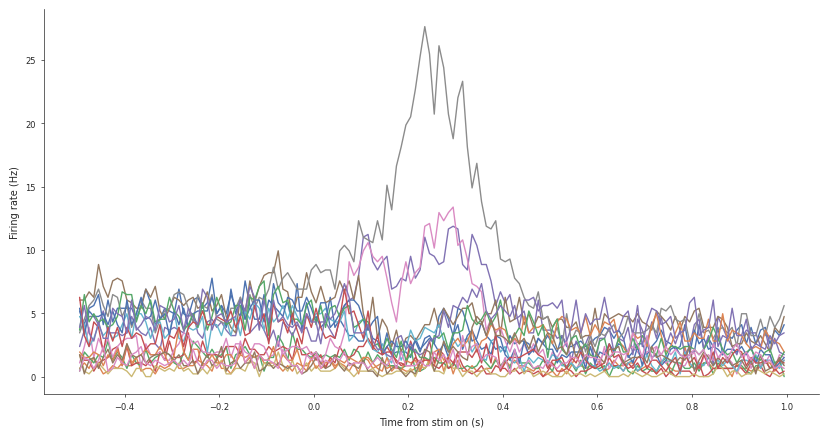

In [ ]:
idx_reg = df['acronym'] == 'VISam'
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(meta['times'], psth[idx_reg, :].T)
ax.set_xlabel('Time from stim on (s)')
ax.set_ylabel('Firing rate (Hz)')

Text(0, 0.5, 'Firing rate (Hz)')

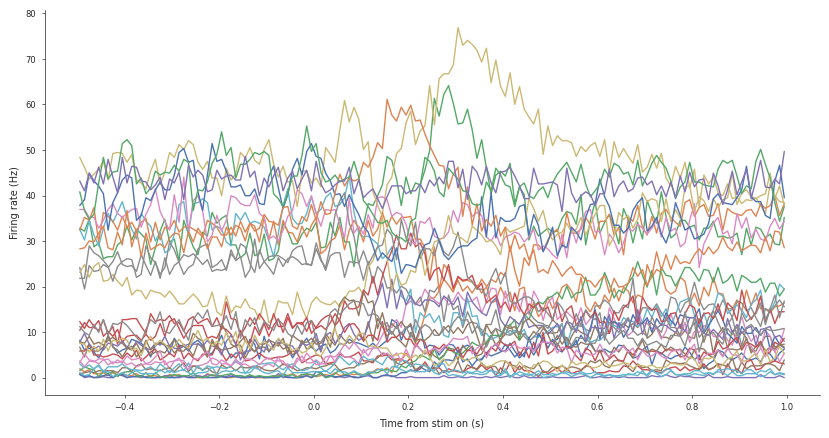

In [ ]:
idx_reg = df['acronym'] == 'APN'
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(meta['times'], psth[idx_reg, :].T)
ax.set_xlabel('Time from stim on (s)')
ax.set_ylabel('Firing rate (Hz)')

### **Identifying responsive cells**

To find **stimulus-responsive cells**, we can **compare the firing rates** of the clusters in defined **pre and post-stimulus time windows**. Here, we use a 50 ms window before the stimulus onset (-0.3 to -0.25 s) and a 50 ms window after (0.05 to 0.1 s):

In [ ]:
pre_time = [-0.3, -0.25]
post_time = [0.05, 0.1]
pre_time_idx = np.bitwise_and(meta['times'] >= pre_time[0], meta['times'] <= pre_time[1])
post_time_idx = np.bitwise_and(meta['times'] >= post_time[0], meta['times'] <= post_time[1])

We can then compute the **average firing rate of the PSTH** in these two intervals and add them as new columns to our DataFrame.

In [ ]:
df['pre'] = np.mean(psth[:, pre_time_idx], axis=1)
df['post'] = np.mean(psth[:, post_time_idx], axis=1)

To identify responsive units, we will compute the **modulation index (MI)**. The formula is:

$$
MI = \frac{\left| \text{pre} - \text{post} \right|}{\left| \text{pre} + \text{post} \right|}
$$

where $\text{pre}$ is the value before the event, and $\text{post}$ is the value after the event.

🟨 **Note:**

*   We are taking the absolute value at the top, so we will not be able to differentiate if a cluster decreases or increases its activity -  we will only be able to state that the difference in activity between pre and post is large.
*   There are other methods to assess whether a cluster is responsive. For example, you could do a paired t-test on the activity at each trial pre/ post and measure whether the response is significantly different.




In [ ]:
df['modulation_idx'] = (df['pre'] - df['post']).abs() / (df['pre'] + df['post']).abs()

We can plot the modulation index for the clusters

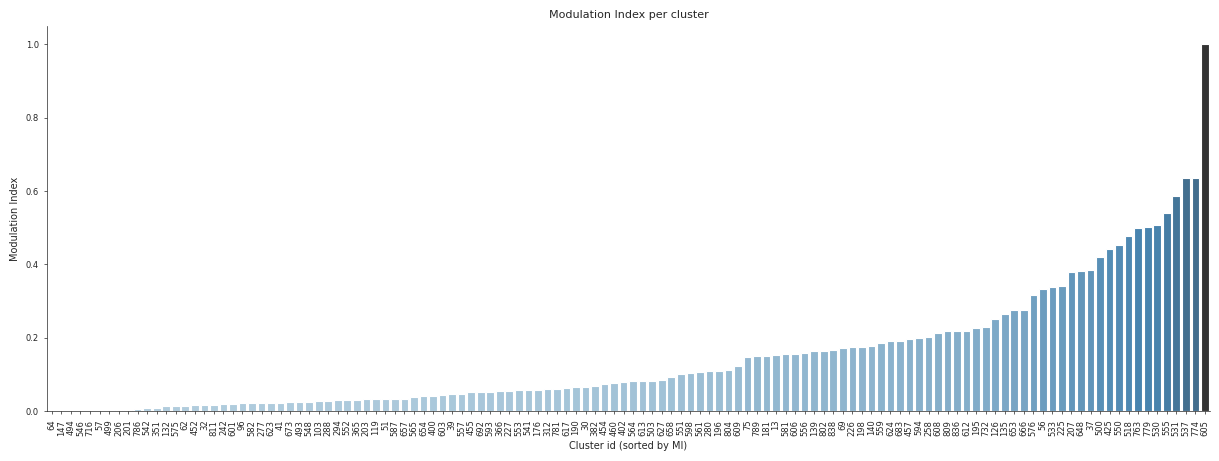

In [ ]:
# Sort cluster IDs by modulation index for plotting
df['ordered_clusters'] = df['cluster_id'].values[df['modulation_idx'].values.argsort()]

fig, ax = plt.subplots(figsize=(15, 5))
sns.barplot(data=df, x='cluster_id', y='modulation_idx', order=df['ordered_clusters'].values,
            palette='Blues_d', hue='modulation_idx', legend=False, ax=ax)

ax.set_xlabel('Cluster id (sorted by MI)')
ax.set_ylabel('Modulation Index')
ax.set_title('Modulation Index per cluster')
ax.tick_params(axis='x', rotation=90)

🟨 **Note:**

*   Some clusters do not have any bars - these are the ones where the denominator is 0, thus the MI = NaN.
*   The clusters with MI = 1 are clusters that had no firing rate in one of the two windows.


Let's assume that the responsive cells are the ones at the top of the distribution, e.g. **the 95th percentile**.


In [ ]:
# Calculate the 95th percentile of the modulation index
percentile_95 = df['modulation_idx'].quantile(0.95)

# Filter clusters with modulation index >= 95th percentile and those less than 1
high_mi_clusters = df[np.bitwise_and(df['modulation_idx'] >= percentile_95, df['modulation_idx'] < 1)]

# Store the index of the modulated clusters
modulated_clusters = high_mi_clusters['psth_index'].values

We can display the information about these **high modulation index clusters** and also plot their PSTHs.

In [ ]:
# Display the result
print("Clusters with modulation index in the 95th percentile or higher:")
high_mi_clusters

Clusters with modulation index in the 95th percentile or higher:


,acronym,pid,uuids,cluster_id,psth_index,pre,post,modulation_idx,ordered_clusters
8008,VISpm,0393f34c-a2bd-4c01-99c9-f6b4ec6e786d,ebcf8d49-7b96-40ee-b085-51cd82f70aad,530,60,3.930886,12.051836,0.508108,402
8009,VISpm,0393f34c-a2bd-4c01-99c9-f6b4ec6e786d,150b3cef-8333-4309-8368-75edcbf5af0e,531,61,2.203024,8.466523,0.587045,564
8011,VISpm,0393f34c-a2bd-4c01-99c9-f6b4ec6e786d,a733c417-60b3-4a62-a586-7c61cb11a599,537,63,0.086393,0.388769,0.636364,503
8020,VISpm,0393f34c-a2bd-4c01-99c9-f6b4ec6e786d,8842a421-1473-4959-bde3-3c1b95032d4d,555,72,4.017279,13.434125,0.539604,609
8059,VISpm,0393f34c-a2bd-4c01-99c9-f6b4ec6e786d,dae1a406-3fc8-4cbe-80b7-21f59c9b88c0,774,111,0.388769,0.086393,0.636364,425
8060,VISpm,0393f34c-a2bd-4c01-99c9-f6b4ec6e786d,5b4b484e-d4c8-40c7-a6e7-84213ca91dd1,779,112,3.369330,10.151188,0.501597,550


Text(0, 0.5, 'Firing rate (Hz)')

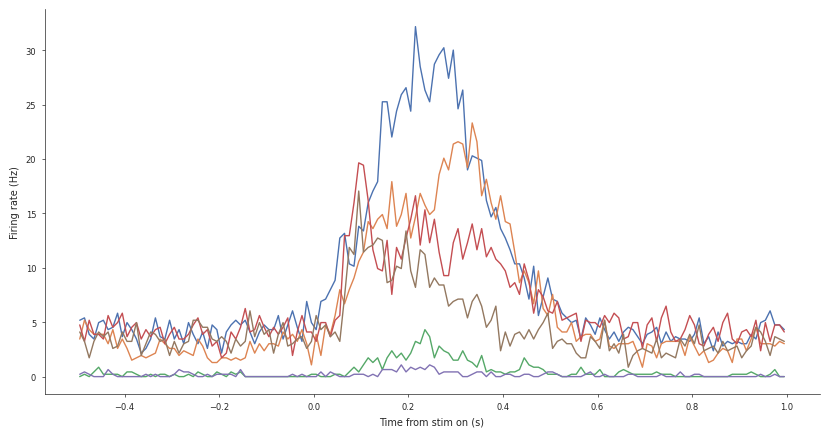

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(meta['times'], psth[high_mi_clusters['psth_index'].values, :].T)
ax.set_xlabel('Time from stim on (s)')
ax.set_ylabel('Firing rate (Hz)')

### **Detecting the latency of response**

We can explore the latency of the response by identifying the **timepoint of the peak response** following stimulus onset. Here we will apply a gaussian filter to the PSTH signal and estimate the latency as the peak of the response post stimlus onset, i.e **t > 0 s**.

Let's compute the latency of the response for the modulated clusters in the previous section.

In [ ]:
psth_mod = psth[modulated_clusters, :]
psth_filt = gaussian_filter1d(psth[modulated_clusters, :], sigma=1)

time_window = meta.times > 0
latency = np.argmax(psth_filt[:, time_window], axis=1)
latency_time = meta.times[time_window][latency]

high_mi_clusters = high_mi_clusters.assign(latency=latency_time)

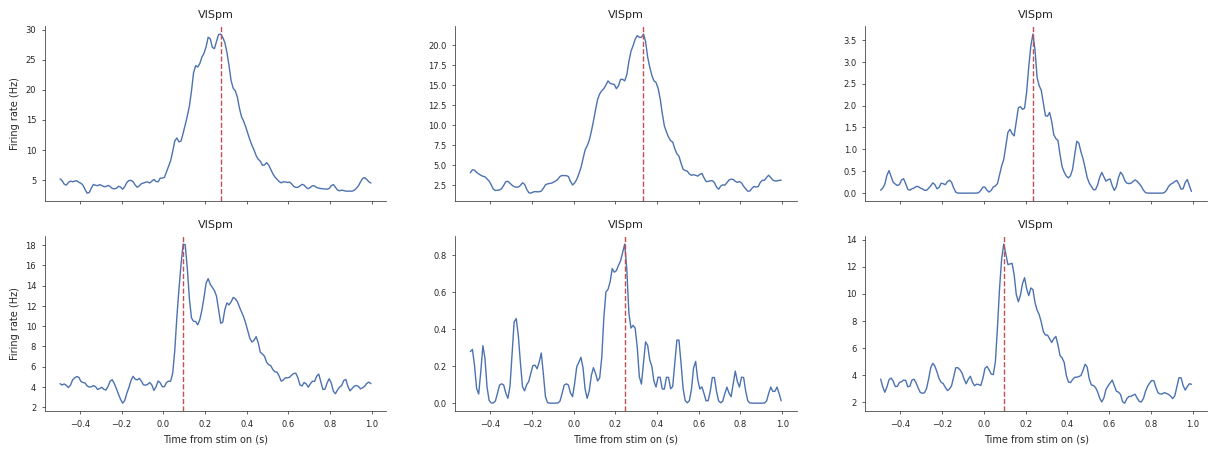

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(15, 5), sharex=True)
axs = axs.ravel()
for i, mod in enumerate(psth_filt):
  axs[i].plot(meta.times, mod)
  axs[i].axvline(latency_time[i], linestyle='--', c='r')
  axs[i].set_title(high_mi_clusters.iloc[i]['acronym'])
  if i > 2:
    axs[i].set_xlabel('Time from stim on (s)')
  if i in [0, 3]:
    axs[i].set_ylabel('Firing rate (Hz)')

We can explore the **mean latency per region** by grouping our DataFrame by region.

In [ ]:
high_mi_clusters.groupby('acronym')['latency'].mean()

,latency
acronym,
VISpm,0.213333


### **Splitting responses by trial type**

In the examples above we computed the firing rate averaged across all trials. However, we can also split by **trial type** to see how the PSTH varies.

For example, we can split by **stimulus** side, i.e whether the stimulus was shown on the left or right of the screen. To do this we add an extra argument to the `get_avg_psth_for_insertion` function called **`split`**


In [ ]:
psth, df = get_avg_psth_for_insertion(pid, meta, split='stimulus')

In this case `psth` is returned as a dict that contains the averaged PSTH for each cluster for the different trial conditions, e.g left and right stimulus.

In [ ]:
print(f'keys in psth are {psth.keys()}')

keys in psth are dict_keys(['left', 'right'])


For the responsive cells that we identified above, we can plot the PSTH response for the different stimulus sides.

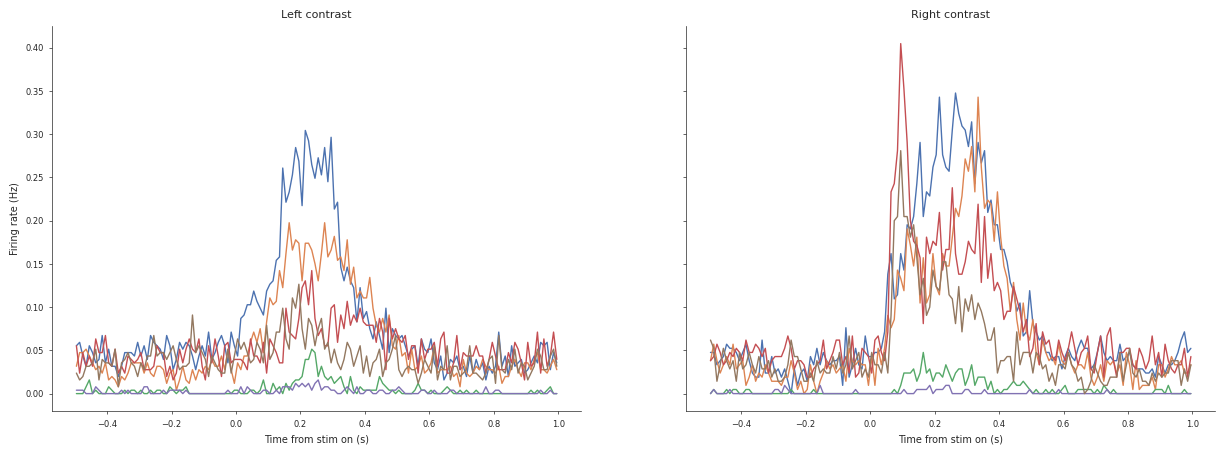

In [ ]:
fig, axs = plt.subplots(1, len(psth), figsize=(15, 5), sharey=True)
for i, (key, vals) in enumerate(psth.items()):
  axs[i].plot(meta['times'], psth[key][modulated_clusters, :].T)
  axs[i].set_title(f'{key.capitalize()} contrast')
  axs[i].set_xlabel('Time from stim on (s)')
  if i == 0:
    axs[i].set_ylabel('Firing rate (Hz)')

We can also split by stimulus **contrast**.

In [ ]:
psth, df = get_avg_psth_for_insertion(pid, meta, split='contrast')

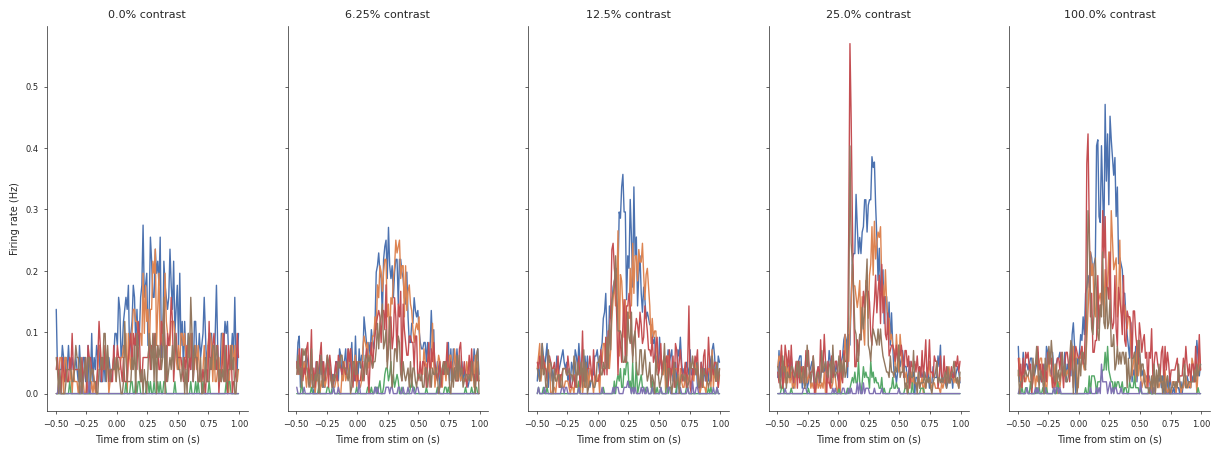

In [ ]:
fig, axs = plt.subplots(1, len(psth), figsize=(15, 5), sharey=True)
for i, (key, vals) in enumerate(psth.items()):
  axs[i].plot(meta['times'], psth[key][modulated_clusters, :].T)
  axs[i].set_title(f'{key}% contrast')
  axs[i].set_xlabel('Time from stim on (s)')
  if i == 0:
    axs[i].set_ylabel('Firing rate (Hz)')

Other options for the **`split`** argument are:
* **`signedContrast`** - combines stimulus side and contrast, negative values indicate the stimulus was shown on the left, positive values on the right
* **`choice`** - whether the mouse turned the wheel clockwise or anti-clockwise
* **`block`** - the probability of the stimulus appearing on the left or the right of the screen

### **Aggregating data across multiple insertions**


In the examples above, we explored how to analyse data from a single insertion. However, the real strength of the brain-wide map dataset lies in its coverage of **many insertions across the brain**. This allows us to pool data from multiple probes and animals, enabling us to explore activity at the **regional level**. In this section, we'll demonstrate how to combine data across insertions to investigate region-wide responses.

Let's explore activity in the region **VISam**. We are going to pool data for VISam from multiple probe insertions.

For this we have a helper function **`get_avg_psth_for_region`**. This behaves in the same way as `get_avg_psth_for_insertion` that we have been using above, but instead of passing in a `pid`, we pass in a **`region`**

In [ ]:
psth, df = get_avg_psth_for_region('VISam', meta)
print(f'{len(df)} clusters from {df["pid"].nunique()} insertions')

374 clusters from 23 insertions


Similar to above we can compute the **modulation index** to identify **responsive cells**.

In [ ]:
df['pre'] = np.mean(psth[:, pre_time_idx], axis=1)
df['post'] = np.mean(psth[:, post_time_idx], axis=1)
df['modulation_idx'] = (df['pre'] - df['post']).abs() / (df['pre'] + df['post']).abs()

idx_mod = np.bitwise_and(df['modulation_idx'] > 0.3, df['modulation_idx'] < 1)
print(f'{idx_mod.sum()}/{len(idx_mod)} of clusters are modulated')

87/374 of clusters are modulated


We can plot the PSTH of the modulated clusters as well as the average across all modulated clusters

Text(0, 0.5, 'Firing rate (Hz)')

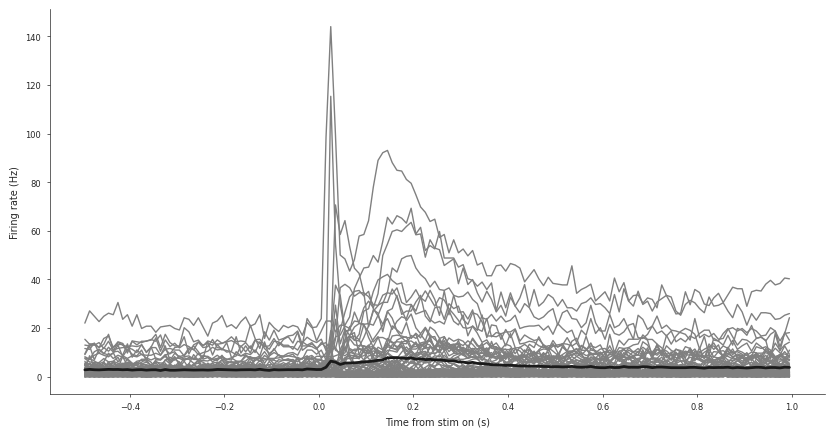

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(meta['times'], psth[idx_mod, :].T, c='grey')
ax.plot(meta['times'], psth[idx_mod, :].mean(axis=0), c='k', lw=2)
ax.set_xlabel('Time from stim on (s)')
ax.set_ylabel('Firing rate (Hz)')

If we now only want to explore the trial dependent response specifically for the modulated clusters that we have found, we can use a third helper function **`get_avg_psth_for_clusters`**. This function allows you to pass in a set of **cluster uuids** to compute the PSTH values.

For instance, if we've already identified clusters in VISam that are significantly modulated by stimulus onset, we can now investigate whether their responses differ depending on the **stimulus side**. The unique identifier for each cluster is stored in the **`uuids`** column.

In [ ]:
uuids = df.loc[idx_mod].uuids.values
psth_test, df_test = get_avg_psth_for_clusters(uuids, meta, split='stimulus')

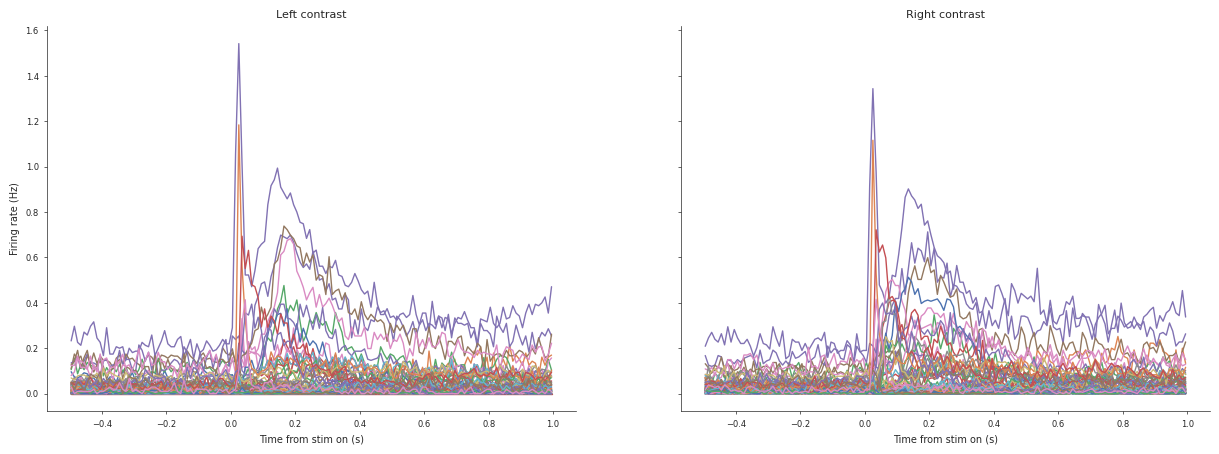

In [ ]:
fig, axs = plt.subplots(1, len(psth_test), figsize=(15, 5), sharey=True)
for i, (key, vals) in enumerate(psth_test.items()):
  axs[i].plot(meta['times'], psth_test[key].T)
  axs[i].set_title(f'{key.capitalize()} contrast')
  axs[i].set_xlabel('Time from stim on (s)')
  if i == 0:
    axs[i].set_ylabel('Firing rate (Hz)')

Q1 (NMA)

Loaded 122 clusters with 150 time bins.

--- Top 5 Most Responsive Units ---
      cluster_id acronym       pre      post  modulation_idx
8011         537   VISpm  0.075594  0.917927        0.847826
7951          37     MRN  0.118790  1.414687        0.845070
8003         494    root  0.064795  0.583153        0.800000
8005         500    root  0.248380  1.598272        0.730994
7955          56     APN  0.291577  1.447084        0.664596


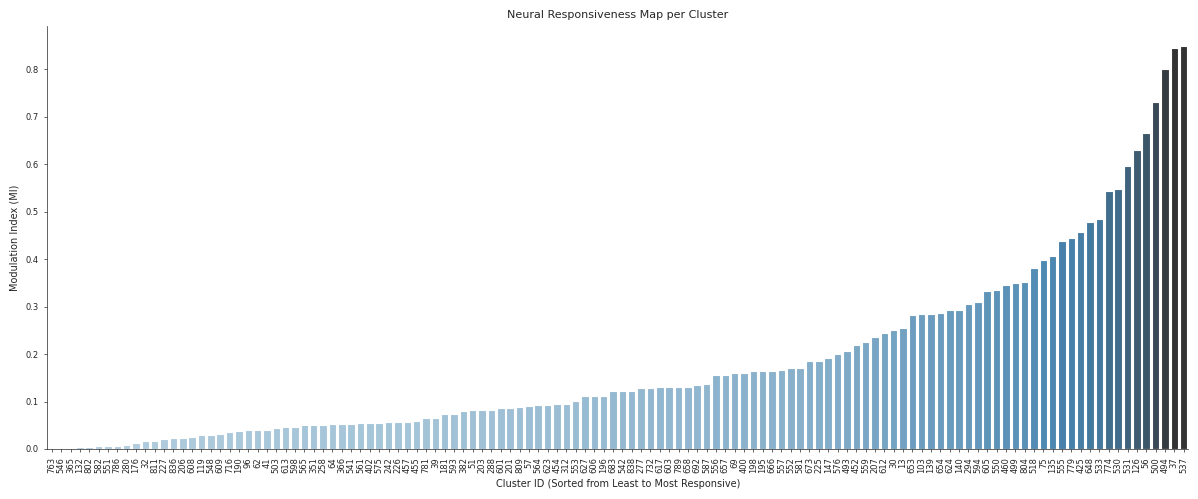

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. DOWNLOAD & LOAD THE STIMULUS DATA
# ==========================================
# (Ensure your ONE setup has been completed as shown in the notebook setup)
download_data('stimOn')
meta = load_metadata('stimOn')

# Let's pick a specific probe insertion (pid) to analyze
# (e.g., one that records from the visual areas)
pid = "0393f34c-a2bd-4c01-99c9-f6b4ec6e786d"

# Load the peri-stimulus time histogram (PSTH) arrays for this insertion
psth, df, trials = get_psth_for_insertion(pid, meta)

# Average across all trials to get the mean response over time for each cluster
# Shape of mean_psth becomes: (number_of_clusters, number_of_time_bins)
mean_psth = psth.mean(axis=0)

print(f"Loaded {mean_psth.shape[0]} clusters with {mean_psth.shape[1]} time bins.")

# ==========================================
# 2. DEFINE PRE AND POST STIMULUS WINDOWS
# ==========================================
# The `meta['times']` array tells us what time each bin represents (relative to stimOn at 0.0s)
# Let's look at a 200ms window before the stimulus and a 200ms window right after
pre_time_idx = (meta['times'] >= -0.2) & (meta['times'] < 0.0)
post_time_idx = (meta['times'] >= 0.0) & (meta['times'] <= 0.2)

# Compute average firing rate per neuron in the 'pre' and 'post' windows
df['pre'] = np.mean(mean_psth[:, pre_time_idx], axis=1)
df['post'] = np.mean(mean_psth[:, post_time_idx], axis=1)

# ==========================================
# 3. CALCULATE THE MODULATION INDEX (MI)
# ==========================================
# Using the standard absolute difference formula
df['modulation_idx'] = (df['pre'] - df['post']).abs() / (df['pre'] + df['post']).abs()

# Sort the clusters by how responsive they are
df['ordered_clusters'] = df['cluster_id'].values[df['modulation_idx'].values.argsort()]

# ==========================================
# 4. SHOW RESULTS & VISUALIZE
# ==========================================
# Let's see the top 5 most responsive units
print("\n--- Top 5 Most Responsive Units ---")
print(df.sort_values(by='modulation_idx', ascending=False)[['cluster_id', 'acronym', 'pre', 'post', 'modulation_idx']].head())

# Plot the Modulation Index across all clusters in this probe insertion
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=df,
    x='cluster_id',
    y='modulation_idx',
    order=df['ordered_clusters'].values,
    palette='Blues_d',
    hue='modulation_idx',
    legend=False,
    ax=ax
)
ax.set_xlabel('Cluster ID (Sorted from Least to Most Responsive)')
ax.set_ylabel('Modulation Index (MI)')
ax.set_title('Neural Responsiveness Map per Cluster')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

## **5. Exploring movement aligned data**

In the previous section, we analysed neural responses aligned to stimulus onset. However, we have also prepared a dataset with PSTHs aligned to the onset of the mouse's **first movement**. This alignment enables us to examine neural activity associated with  **choice** i.e. whether it chooses to turn the wheel left or right in response to the stimulus.

### **Downloading and loading in data for movement onset**

In [ ]:
# Download the data
download_data('firstMove')
# Load in the metadata
meta = load_metadata('firstMove')

(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/Neuromatch/data_firstMove.zip: 100%|██████████| 823M/823M [00:11<00:00, 71.1MB/s]


### **Analyzing choice related neural activity using PCA**

One analysis that we can perform is to examine **when** the neural activity representing left versus right choices begins to diverge before the first movement is made. We will use a dimensionality reduction approach (PCA) to measure the **distance between the left and right choice representations** over a time window of interest.


We start by loading data from a specific brain region of interest, **GRN**. The trials are then split based on the **choice** made.

In [ ]:
# Look at example region. We want to split by choice
psth, df = get_avg_psth_for_region('GRN', meta, split='choice')

We will then construct a high-dimensional representation of the neural activity by **stacking the average PSTHs** from each cluster. Here, each dimension corresponds to one cluster’s activity.

Since we are interested in the time before the first movement, we restrict our analysis to the time window where **t < 0 s**.

In [ ]:
# Stack PSTHs for right (1, CW) and left (-1, CCW) choice
time_window = meta.times < 0
all_psth = np.concatenate([psth[1.0][:, time_window], psth[-1.0][:, time_window]], axis=1)

We then apply PCA to reduce the dimensionality of the neural data to **two principal components** and extract the trajectories for left and right choice.

In [ ]:
# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
trajs = pca.fit_transform(all_psth.T).T

# Extract trajectories for left and right choice
traj_right = trajs[:, :time_window.sum()]
traj_left = trajs[:, time_window.sum():]

To quantify how the neural representations for the two choices diverge over time, we compute the **Euclidean distance** between their trajectories at each time point.

In [ ]:
euc_dist = np.sqrt(np.sum((traj_left - traj_right) ** 2, axis=0))

We can estimate the **latency** at which the trajectories diverge as the time point at which the Euclidean distance is **70% of it's maximum value**.

In [ ]:
latency_idx = np.argmax(euc_dist > np.max(euc_dist) * 0.7)
latency = meta.times[time_window][latency_idx]

We can visualize both the low-dimensional trajectories and the evolution of their Euclidean distance leading up to the first movement.

Text(0, 0.5, 'Euclidian distance')

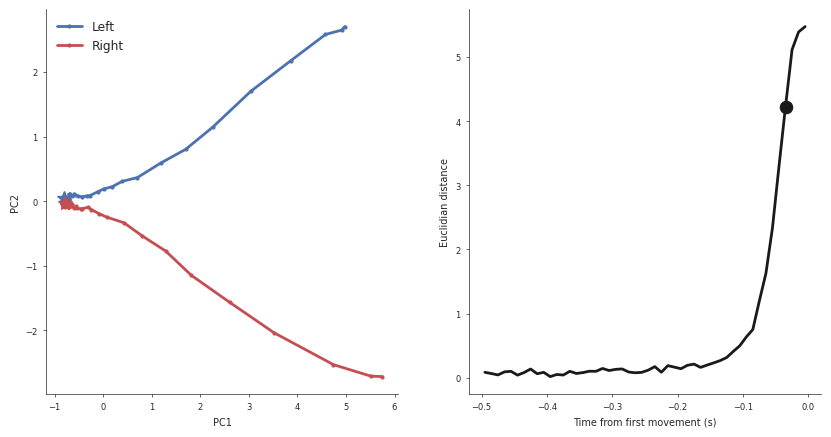

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plot the trajectories
axs[0].plot(traj_left[0, :], traj_left[1, :], color='b', label='Left',  marker='.', lw=2)
axs[0].plot(traj_right[0, :], traj_right[1, :], color='r', label='Right',  marker='.', lw=2)
# Mark the start
axs[0].plot(traj_left[0, 0], traj_left[1, 0], color='b', marker='*', ms=10)
axs[0].plot(traj_right[0, 0], traj_right[1, 0], color='r', marker='*', ms=10)
axs[0].set_xlabel('PC1')
axs[0].set_ylabel('PC2')
axs[0].legend(loc=2, frameon=False)

axs[1].plot(meta.times[time_window], euc_dist, color='k', lw=2)
axs[1].scatter(latency, euc_dist[latency_idx], color='k', s=80)
axs[1].set_xlabel('Time from first movement (s)')
axs[1].set_ylabel('Euclidian distance')

### **Decoding choice from neural activity**

In this section, we will explore whether we can **predict the mouse's choice** (i.e. left or right movement) based on neural activity using **trial-level PSTH data**.

Unlike the previous analyses, which averaged firing rates across trials, we will need to have access to the data on the individual trial level. To facilitate this, we provide three helper functions that return the trial-level data:

* `get_psth_for_insertion`
* `get_psth_for_region`
* `get_psth_for_clusters`


The function **`get_psth_for_insertion`** loads trial-level data for a specified pid. The function returns three objects:

1. A 3D array of shape `n_trials x n_clusters x n_times` containing the PSTH for the specified pid

2. A dataframe describing the clusters for the specified pid

3. A dataframe describing the trials for the specified pid


In [ ]:
pid = '8ca1a850-26ef-42be-8b28-c2e2d12f06d6'
psth, clust_df, trials_df = get_psth_for_insertion('8ca1a850-26ef-42be-8b28-c2e2d12f06d6', meta)

print(psth.shape)
print(len(clust_df))
print(len(trials_df))

(569, 172, 150)
172
569


The functions **`get_psth_for_region`** and **`get_psth_for_clusters`** return lists of PSTH arrays, cluster metadata, and trial tables, each corresponding to one probe insertion.

For example, the region VISam has data from 23 separate insertions, so the lists will have length 23.

In [ ]:
psth, clust_reg, trials_reg = get_psth_for_region('VISam', meta)

print(len(psth))
print(len(clust_reg))
print(len(trials_reg))

23
23
23


We will now demonstrate how to decode the mouse's choice. As choice is a **binary variable (+1, -1)** we will use **logistic regression** on the activity of all clusters from a single insertion.

In [ ]:
psth, clust_df, trials_df = get_psth_for_insertion('8ca1a850-26ef-42be-8b28-c2e2d12f06d6', meta)

time_mask = np.bitwise_and(meta.times < 0, meta.times > -0.1)
X = psth[:, :, time_mask].mean(axis=2)
y = trials_df.choice.values

# Split trials in half into test and training sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

# Fit the logistic regression model
clf = LogisticRegression(random_state=0, max_iter=1000).fit(X_train, y_train)

# Use the test set to assess the model accuracy
choice_predicted = clf.predict(X_test)
n_trial_correct = (y_test == choice_predicted).sum()
print(f'{n_trial_correct}/{len(y_test)} trials correctly predicted')
print(f'Accuracy: {np.round(n_trial_correct/len(y_test), 2) * 100} %')


225/285 trials correctly predicted
Accuracy: 79.0 %


🟨 **Note**
* In this example, we used a 50/50 train-test split. For a more robust estimate of model performance, you could use leave-one-out cross-validation. This involves training the model on all trials except one, predicting the held-out trial, and repeating for each trial, maximizing the amount of training data used in each iteration.


## **6. Example of a brainwide analysis**

In this section, we will walk through how to extend your analysis across **all brain regions** included in the dataset. For example, suppose we want to identify which regions are **most responsive to stimulus onset**. To do this, we will return to the **modulation index (MI)** metric introduced earlier, using it to quantify and compare the number of responsive clusters in each region.



In [ ]:
# Get meta data for stimulus onset
meta = load_metadata('stimOn')
# Find the regions contained in our dataset
regions = meta.clusters['acronym'].unique()

In [ ]:
# Define pre and post window timepoints
pre_time = [-0.3, -0.25]
post_time = [0.05, 0.1]
pre_time_idx = np.bitwise_and(meta['times'] >= pre_time[0], meta['times'] <= pre_time[1])
post_time_idx = np.bitwise_and(meta['times'] >= post_time[0], meta['times'] <= post_time[1])

# Define threshold to detect responsive cells
threshold = 0.3


# Loop over the regions and compute the modulation index for all cells
all_modulated = []
for reg in regions:
  # Ignore root and void where clusters are unassigned
  if reg in ['root', 'void']:
    continue
  psth, df = get_avg_psth_for_region(reg, meta)
  df['pre'] = np.mean(psth[:, pre_time_idx], axis=1)
  df['post'] = np.mean(psth[:, post_time_idx], axis=1)
  df['modulation_idx'] = (df['pre'] - df['post']).abs() / (df['pre'] + df['post']).abs()
  df['modulated'] = np.bitwise_and(df['modulation_idx'] >= threshold, df['modulation_idx'] < 1)

  all_modulated.append(df)

# Concatenate results into a single dataframe
all_modulated = pd.concat(all_modulated)

We can then group the data by brain region to create a new DataFrame that summarizes, for each region, both the **percentage of responsive clusters** and the **total number of clusters** recorded.

In [ ]:
res = pd.DataFrame()
res['percentage'] = all_modulated.groupby('acronym')['modulated'].sum() / all_modulated.groupby('acronym')['modulated'].count()
res['n_clusters'] = all_modulated.groupby('acronym')['modulated'].count()

We will plot the top 20 brain regions with the largest percentage of clusters with a high modulation index.

Text(0, 0.5, 'Percentage of responsive clusters')

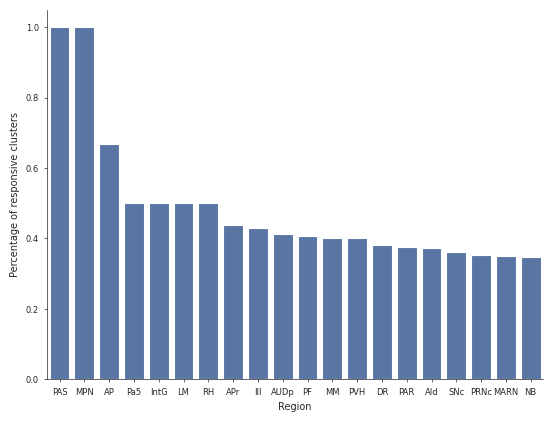

In [ ]:
res_sort = res.sort_values('percentage', ascending=False)
n_reg = 20
fig, ax = plt.subplots()
sns.barplot(x='acronym', y='percentage', data=res_sort[0:n_reg], ax=ax)
ax.set_xlabel('Region')
ax.set_ylabel('Percentage of responsive clusters')

Note that, so far, we have included all brain regions without applying any filters based on the number of recorded clusters or their firing rates. As a result, some regions may appear to have a high percentage of modulated cells simply because they contain very few clusters, which can be misleading.

To obtain more robust results, we will now **restrict our analysis** to regions that have **more than 200 recorded clusters**. This will allow us to more reliably identify regions with the highest number of responsive cells.

Text(0, 0.5, 'Percentage of responsive cells')

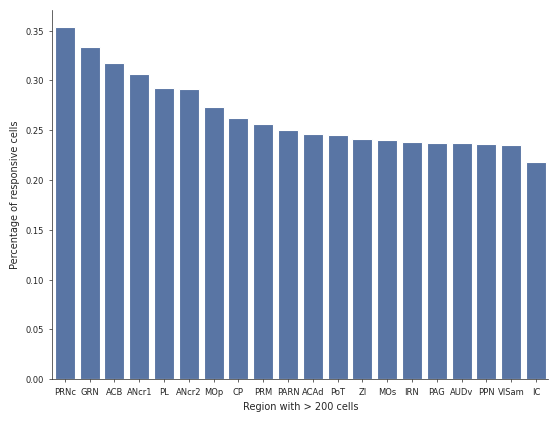

In [ ]:
n_clust = 200
res_filt = res[res['n_clusters'] >= n_clust]
res_sort = res_filt.sort_values('percentage', ascending=False)
n_reg = 20

fig, ax = plt.subplots()
sns.barplot(x='acronym', y='percentage', data=res_sort[0:n_reg], ax=ax)
ax.set_xlabel('Region with > 200 cells')
ax.set_ylabel('Percentage of responsive cells')

The top five regions with the highest proportion of responsive clusters are **PRNc**, **GRN**, **ACB**, **ANcr1**, and **ANcr2**, each with over **25%** of clusters showing significant modulation in response to stimulus onset.

This observation aligns well with findings from the [International Brain Lab paper](https://doi.org/10.1101/2023.07.04.547681).

📔 *A Brain-Wide Map of Neural Activity during Complex Behaviour - International Brain Laboratory et al.*



In particular, most of these regions are consistently identified as being responsive to visual stimuli across at least **three out of four** independent analysis methods presented in the study.

Below is a snapshot of Figure 5 from the paper, with **PRNc** and **GRN** highlighted.

![](https://ibl-brain-wide-map-public.s3.us-east-1.amazonaws.com/sample_data/Neuromatch/figures/stimulus_bwm.png)

## **7. Exploring the block variable**

In this section, we will study how the mice are able to track the **block prior** (i.e. the probability of the visual stimulus to appear most likely on one side of the screen). As the block change is not cued, mice have to **integrate** over the past trials. We will review the literature showing this temporal integration, and perform a decoding analysis at different timepoints (early or late) in blocks.


We will review plots from Fig 1 of [this article](https://doi.org/10.1101/2023.07.04.547684):

📔 *Brain-wide representations of prior information in mouse
decision-making - Findling, Hubert, International Brain Laboratory et al.*



As a reminder, during the task the contrast of the visual stimulus changes, ranging from 100% (fully visible) to 0% (invisible).


In addition, the probability of the stimulus appearing on the left side of the screen varies in blocks of trials.



![](https://ibl-brain-wide-map-public.s3.us-east-1.amazonaws.com/sample_data/Neuromatch/figures/task_recap.png)

The mice can use this probability information to attempt to obtain rewards even during 0% contrast trials, when no visual stimulus is present on the screen.

This strategy is evident in their psychometric curves: on 0% contrast trials, mice tend to bias their responses toward the side associated with the current block.

This bias is weaker during 100% contrast trials, where the stimulus is clearly visible and mice are able to make accurate choices with high reliability.

![](https://ibl-brain-wide-map-public.s3.us-east-1.amazonaws.com/sample_data/Neuromatch/figures/biased_performance.png)

**But how do they know which block they are in?**

Since the block switches are not cued, an observer would need to integrate information over several past trials to form a prior about the current block identity.

We can see that mice do such integration, as shown by their performance on 0% contrast trials over the course of a block.

*   On `early` trials within a block, mice tend to perform poorly.
*   On `later` trials, their performance improves, indicating a growing certainty about the block identity.

![](https://ibl-brain-wide-map-public.s3.us-east-1.amazonaws.com/sample_data/Neuromatch/figures/trial_early_late_block.png)

We can replicate this result with our trials table data and using the columns `block` and `block_trial_number` to find examples of these **`early` (<= 2 trials since block change)** and **`late` (> 15 trials since block change)** trials for **0 % and 100 % contrast** stimuli.

In [ ]:
# Load in meta data that has the trials table
meta = load_metadata('stimOn')
trials = meta.trials

We will add three new columns to our trials table
* `contrast` the absolute contrast of the visual stimulus
* `correct` the correct trials

and
* `block_timing` where we annotate the first 0 or 100 % trial that matches the `early` or `late` trial type condition



In [ ]:
trials = trials.assign(contrast=np.nansum([trials['contrastLeft'], trials['contrastRight']], axis=0))
trials = trials.assign(correct=trials['feedbackType'] == 1)

queries = []
# early trials with 0% contrast
queries.append('block_trial_number <= 2 and contrast == 0 and probabilityLeft != 0.5')
# early trials with 100% contrast
queries.append('block_trial_number <= 2 and contrast == 1 and probabilityLeft != 0.5')
# late trials with 0% contrast
queries.append('block_trial_number > 15 and contrast == 0 and probabilityLeft != 0.5')
# late trials with 100% contrast
queries.append('block_trial_number > 15 and contrast == 1 and probabilityLeft != 0.5')

trial_type = ['Early', 'Early', 'Late', 'Late']

for query, val in zip(queries, trial_type):
  idx = trials.query(query).drop_duplicates(subset=['eid', 'block'], keep='first')
  mask = trials.index.isin(idx.index)
  trials.loc[mask, 'block_timing'] = val

# Remove nan trials
trials = trials[~trials['block_timing'].isna()]

We can then group by `block_timing` and `contrast` and compute the proportion of trials that were correct for each condition

In [ ]:
trials_grp = trials.groupby(['block_timing', 'contrast'])
prop_correct = trials_grp['correct'].mean()

for grp, p in prop_correct.items():
    print(f'{grp}: {np.round(p * 100, 2)}')

('Early', 0.0): 42.18
('Early', 1.0): 97.62
('Late', 0.0): 62.72
('Late', 1.0): 98.45


This aligns well with the plot above, which shows that the mice's performance on 0% contrast trials improves depending on when the trial occurs relative to the block switch. Performance is lower immediately after a block change and increases as more trials pass within the new block.

We can also see if we are able to decode block from a single recording. We will chooses a time window of between **0.3 to 0.1 ms prior to visual stimulus onset**.

In [ ]:
psth, clust_df, trials_df = get_psth_for_insertion('8ca1a850-26ef-42be-8b28-c2e2d12f06d6', meta)

time_mask = np.bitwise_and(meta.times < -0.1, meta.times > -0.3)
X = psth[:, :, time_mask].mean(axis=2)
# Convert values of 0.2, 0.5, 0.8 to 1, 2, 3 for logistic regression
mapping = {0.2: 1, 0.5: 2, 0.8: 3}
y = trials_df['probabilityLeft'].map(mapping).values

# Split trials in half into test and training sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

# Fit the logistic regression model
clf = LogisticRegression(random_state=0, max_iter=1000).fit(X_train, y_train)

# Use the test set to assess the model accuracy
choice_predicted = clf.predict(X_test)
n_trial_correct = (y_test == choice_predicted).sum()
print(f'{n_trial_correct}/{len(y_test)} trials correctly predicted')
print(f'Accuracy: {np.round(n_trial_correct/len(y_test), 2) * 100} %')

182/285 trials correctly predicted
Accuracy: 64.0 %


### **Going further - Bayes Optimal model**

Mice may use various strategies to perform temporal integration and form a prior about the current block. However, one thing is clear, they are not able to detect block switches as sharply as the actual block transitions occur.

If we use an ideal observer model, known as the **Bayes-optimal model**, the confidence in the block identity would follow the blue curve shown below:


![](https://ibl-brain-wide-map-public.s3.us-east-1.amazonaws.com/sample_data/Neuromatch/figures/block_bayes_optimal.png)

In other words, it is not feasible to decode the block identity exactly as it is defined in the task, as attempted above, because the block switches are uncued. Instead, the most accurate estimate an animal could form about the current block is described by the Bayes-optimal prior.

A more realistic approach, therefore, is to decode this Bayes-optimal prior from neural activity, rather than attempting to decode the true block variable directly from the task design.

You can find an example of how to compute the Bayes-optimal prior and decode it using neural activity from a single session in this [notebook](https://github.com/int-brain-lab/prior-localization/blob/main/prior_localization/decode_single_session.ipynb).


🟨 **Note**
* This analysis requires access to the full dataset, rather than the pre-processed version used above. To get started with accessing the full IBL dataset, please refer to:
  *   [This introductary notebook](https://colab.research.google.com/drive/1_1qfa-DLDbezyFXguFOnJJWF5aJ5AH0i#scrollTo=-TJR7XEgtBxS)
  *   [This tutorial](https://colab.research.google.com/drive/1y3sRI1wC7qbWqN6skvulzPOp6xw8tLm7#scrollTo=hRZA78AoaBIC)


The `Bayes Optimal` model is really the best an animal could do in estimating the block prior. However, mice are likely not that optimal.

The [article](https://doi.org/10.1101/2023.07.04.547684) introduces alternative models that better capture actual mouse behavior, such as the `Action Kernel` model, which incorporates a memory of past actions.

All behavioral models discussed in the paper are available in this [repository](https://github.com/int-brain-lab/behavior_models/tree/main).

### **Going further - Exploring behaviour**

There are many more questions related to block that we can explore related using the behavioral data. Here are a few example questions:

1. 🔍 Take a trial, and look at the values for contrast and block on the previous `N` trials. Consider the contrast as your certainty measure,
meaning for a 100% contrast trial you are sure of the associated block side.

  Given this information, what would be your predicted block side for your current trial? And how correct would you be? How does that vary with `N` size?

2. 🔍  Does the reaction time changes on trials when the visual stimulus appears on the other side than the expected block prior?
Does this effect vary with stimulus contrast?

These can be explored either by using the data prepared for this course of by accessing the [full behavioural dataset](https://colab.research.google.com/github/NeuromatchAcademy/course-content/blob/main/projects/behavior/IBL_behavior_data.ipynb) that is available as part of the behavioural project datasets.

# RQs

## RQ1


--- Regional Responsiveness Leaderboard ---
acronym  total_units  responsive_units  percent_responsive
    MRN            6                 6          100.000000
    CA1           13                 9           69.230769
  VISam           17                11           64.705882
    APN           30                19           63.333333
   root            8                 5           62.500000
     DG            5                 3           60.000000
  VISpm           43                25           58.139535


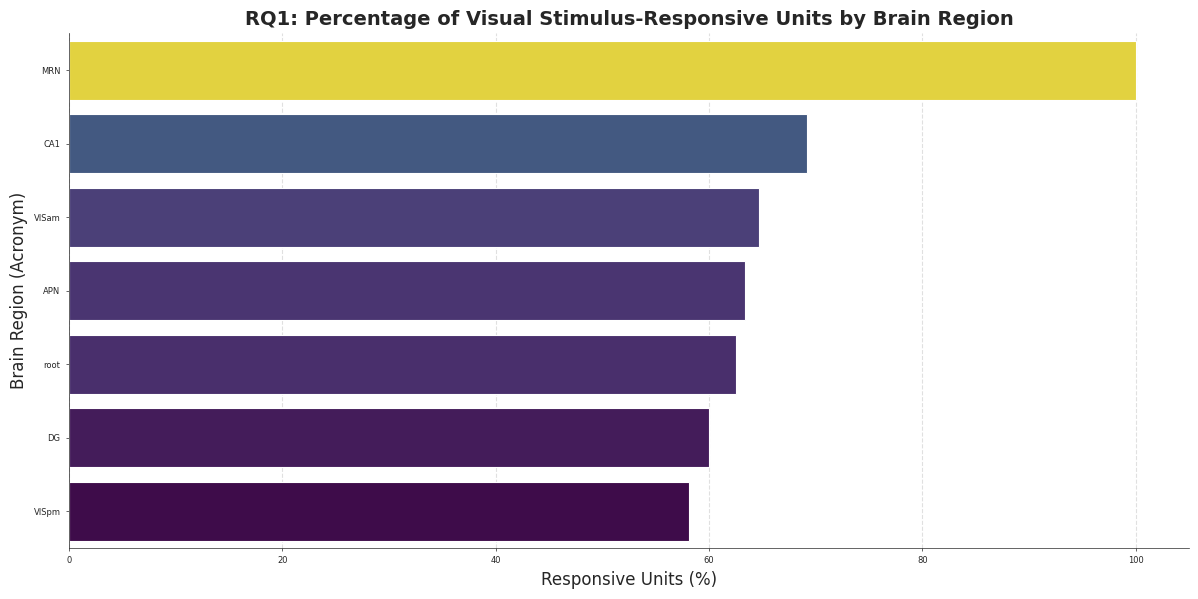

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import statsmodels.stats.multitest as smm

# =====================================================================
# 1. LOAD DATA & METADATA (Aligned to Stimulus Onset)
# =====================================================================
download_data('stimOn')
meta = load_metadata('stimOn')

# Select a representative session / probe insertion id (pid)
pid = "0393f34c-a2bd-4c01-99c9-f6b4ec6e786d"

# Retrieve the PSTH matrices, cluster DataFrame, and trial metadata
psth, df, trials = get_psth_for_insertion(pid, meta)
# psth shape is (n_trials, n_clusters, n_time_bins)

# =====================================================================
# 2. ISOLATE TIME WINDOWS & CALCULATE METRICS PER TRIAL
# =====================================================================
# Identify index masks for the pre-stimulus (-200ms to 0ms) and post-stimulus (0ms to 200ms) bins
pre_window_idx = (meta['times'] >= -0.2) & (meta['times'] < 0.0)
post_window_idx = (meta['times'] >= 0.0) & (meta['times'] <= 0.2)

n_trials, n_clusters, _ = psth.shape
p_values = []
modulation_indices = []

# Loop over every unit (cluster) to test individual trial dynamics
for c in range(n_clusters):
    # Extract firing rates across all trials for the current cluster
    trial_pre_rates = np.mean(psth[:, c, pre_window_idx], axis=1)
    trial_post_rates = np.mean(psth[:, c, post_window_idx], axis=1)

    # Calculate the average Modulation Index (MI) for this cluster across the session
    mean_pre = np.mean(trial_pre_rates)
    mean_post = np.mean(trial_post_rates)

    if (mean_pre + mean_post) == 0:
        mi = 0.0
    else:
        mi = abs(mean_post - mean_pre) / (mean_post + mean_pre)
    modulation_indices.append(mi)

    # Perform a paired Wilcoxon signed-rank test across trials to see if changes are stable
    # If a neuron's firing rate is completely flat (all zeros), catch the variance error
    if np.array_equal(trial_pre_rates, trial_post_rates):
        p_values.append(1.0)
    else:
        stat, p_val = wilcoxon(trial_post_rates, trial_pre_rates)
        p_values.append(p_val)

# Add computed arrays back into our main structural cluster DataFrame
df['p_value'] = p_values
df['modulation_index'] = modulation_indices

# =====================================================================
# 3. MULTIPLE-COMPARISON CORRECTION (FDR)
# =====================================================================
# Because we are testing hundreds of neurons simultaneously, we must correct for false positives
reject, pvals_corrected, _, _ = smm.multipletests(df['p_value'].values, alpha=0.05, method='fdr_bh')
df['is_responsive'] = reject

# =====================================================================
# 4. GROUP BY ANATOMICAL REGION & RANK
# =====================================================================
# Calculate total recorded neurons vs statistically responsive ones per neighborhood
region_stats = df.groupby('acronym').agg(
    total_units=('cluster_id', 'count'),
    responsive_units=('is_responsive', 'sum')
).reset_index()

# Calculate the metric: percent responsive units per region
region_stats['percent_responsive'] = (region_stats['responsive_units'] / region_stats['total_units']) * 100

# Sort the regional leaderboard from most responsive to least responsive
region_stats = region_stats.sort_values(by='percent_responsive', ascending=False)

print("\n--- Regional Responsiveness Leaderboard ---")
print(region_stats[['acronym', 'total_units', 'responsive_units', 'percent_responsive']].to_string(index=False))

# =====================================================================
# 5. VISUALIZE RANKED LEADERBOARD
# =====================================================================
plt.figure(figsize=(12, 6))
sns.barplot(
    data=region_stats,
    x='percent_responsive',
    y='acronym',
    palette='viridis',
    hue='percent_responsive',
    legend=False
)

plt.title('RQ1: Percentage of Visual Stimulus-Responsive Units by Brain Region', fontsize=14, fontweight='bold')
plt.xlabel('Responsive Units (%)', fontsize=12)
plt.ylabel('Brain Region (Acronym)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

The Python code block in cell WQJD3AsACOtV is designed to identify visual stimulus-responsive neurons and then determine which brain regions contain the highest percentage of these responsive units. It addresses 'RQ1' (Research Question 1).

Here's a detailed breakdown of the code:

Load Data & Metadata (Aligned to Stimulus Onset):

It begins by importing necessary libraries like NumPy, Pandas, Matplotlib, Seaborn, wilcoxon for statistical testing, and statsmodels.stats.multitest for multiple comparison correction.

It then downloads and loads the data (meta) aligned to 'stimOn' (stimulus onset) using helper functions download_data and load_metadata.
A specific probe insertion ID (pid) is chosen (e.g.,  "0393f34c-a2bd-4c01-99c9-f6b4ec6e786d"), and the corresponding PSTH (Peri-Stimulus Time Histogram), cluster metadata (df), and trial metadata (trials) are loaded using get_psth_for_insertion. The psth data has dimensions (n_trials, n_clusters, n_time_bins).

Isolate Time Windows & Calculate Metrics Per Trial:

This section defines two critical time windows relative to stimulus onset (0.0s):

pre_window_idx: -200ms to 0ms (pre-stimulus baseline).
post_window_idx: 0ms to 200ms (post-stimulus response).
It then iterates through each neuron (cluster) recorded in the selected probe insertion:

For each neuron, it extracts the firing rates during the pre and post windows across all individual trials (trial_pre_rates, trial_post_rates).
It calculates a Modulation Index (MI) for each cluster, based on the mean firing rates in the pre and post windows: abs(mean_post - mean_pre) / (mean_post + mean_pre). This quantifies the magnitude of change in firing.
Crucially, it performs a paired Wilcoxon signed-rank test for each neuron. This statistical test compares the distribution of trial-by-trial firing rates in the post-stimulus window against the pre-stimulus window. A significant p-value indicates a statistically reliable change in firing rate in response to the stimulus. Special handling is included for cases where firing rates are zero or constant.

The calculated p-values and modulation indices are added as new columns (p_value, modulation_index) to the cluster DataFrame (df).

Multiple-Comparison Correction (FDR):

Since hundreds of statistical tests (one per neuron) are performed, there's a high chance of false positives. To address this, a False Discovery Rate (FDR) correction (Benjamini-Hochberg procedure) is applied to all the p-values.
A new boolean column is_responsive is added to df, indicating whether each neuron is statistically responsive after this stringent correction (True if responsive, False otherwise).

Group by Anatomical Region & Rank:

The code then groups the df by brain region (acronym).
For each region, it calculates the total_units (count of all neurons) and responsive_units (sum of is_responsive neurons).
It then computes the percent_responsive units per region.
Finally, the regions are sorted in descending order based on their percent_responsive metric, creating a "Regional Responsiveness Leaderboard."
Visualize Ranked Leaderboard:

A seaborn.barplot is used to visualize this leaderboard. The x-axis represents the percentage of responsive units, and the y-axis lists the brain regions.
The bars are colored using a 'viridis' palette, and a title clearly labels the plot as "RQ1: Percentage of Visual Stimulus-Responsive Units by Brain Region."

In summary, this code provides a robust method to identify individual neurons that significantly respond to a visual stimulus and then aggregates this information to rank brain regions by their overall responsiveness, providing insight into which brain areas are most engaged in initial visual processing.

Found 698 unique probe insertions across the dataset. Processing neural records...


Processing Sessions: 100%|██████████| 698/698 [02:22<00:00,  4.91it/s]
/tmp/ipykernel_667/604132011.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



Successfully gathered metrics for 75708 total neurons across all sessions.

--- Unified Cross-Session Brain-Wide Visual Responsiveness Leaderboard (Top 15) ---
acronym  total_units  responsive_units  avg_modulation_index  percent_responsive
    CLI           89                74              0.212654           83.146067
     FN           46                38              0.146619           82.608696
    NPC           71                58              0.132787           81.690141
   PGRN          120                98              0.277568           81.666667
    RPF           42                34              0.231675           80.952381
     DN          197               155              0.176639           78.680203
     I5           42                33              0.215898           78.571429
    GRN          560               438              0.327466           78.214286
   MARN           83                64              0.387026           77.108434
    LDT           51         

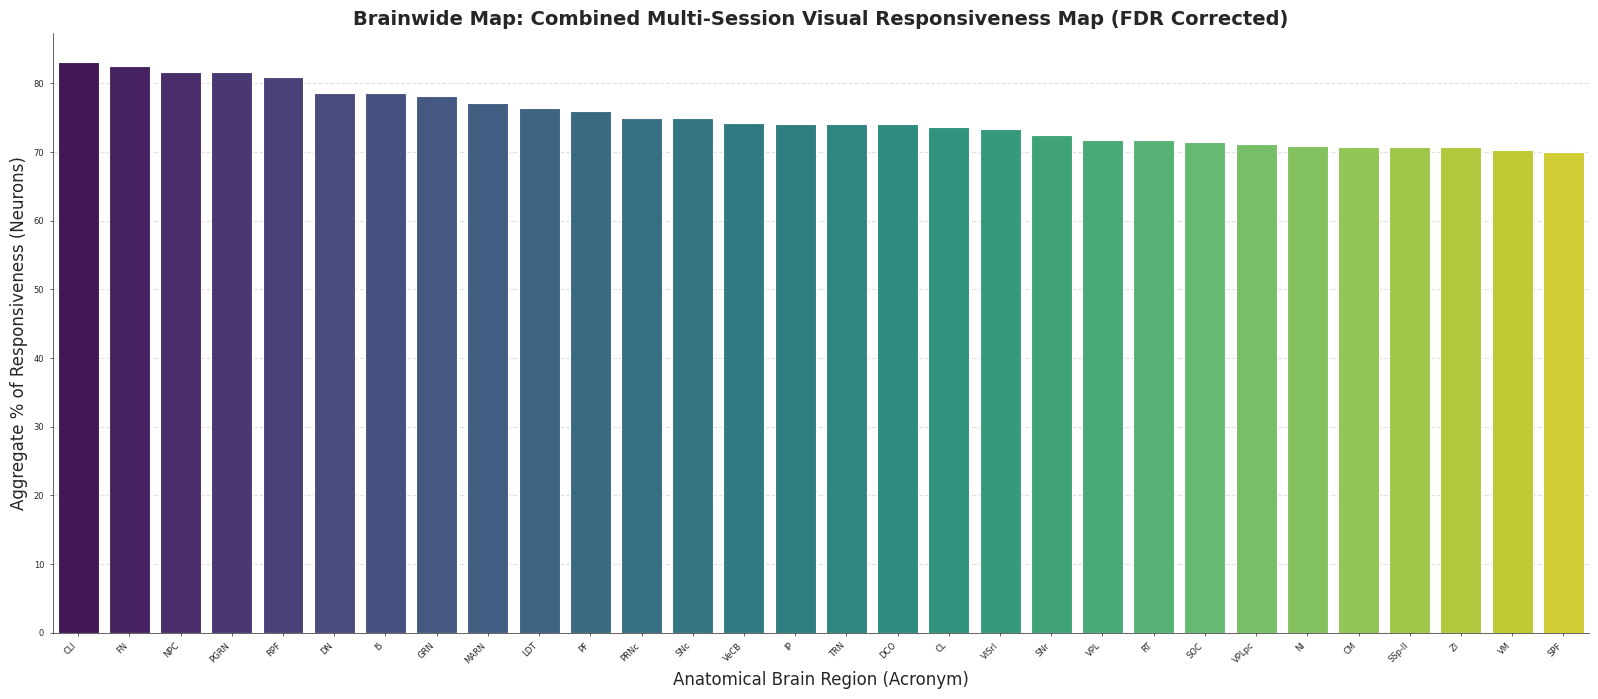

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.stats.multitest as smm
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm  # Visual progress bar for iterating sessions

# =====================================================================
# 1. DOWNLOAD & LOAD GLOBAL METADATA
# =====================================================================
download_data('stimOn')
meta = load_metadata('stimOn')

# Isolate the time epochs relative to stimulus onset (0.0s)
pre_window_idx = (meta['times'] >= -0.2) & (meta['times'] < 0.0)
post_window_idx = (meta['times'] >= 0.0) & (meta['times'] <= 0.2)

# Get every unique probe insertion ID available across all sessions
all_pids = meta.clusters['pid'].unique()
print(f"Found {len(all_pids)} unique probe insertions across the dataset. Processing neural records...")

# A master collector list to accumulate stats for every cell in the brainwide map
global_neuron_records = []

# =====================================================================
# 2. RUN COMPREHENSIVE LOOP OVER ALL INSERTIONS AND NEURONS
# =====================================================================
for pid in tqdm(all_pids, desc="Processing Sessions"):
    try:
        # Filter metadata clusters belonging specifically to this probe insertion
        pid_clusters = meta.clusters[meta.clusters['pid'] == pid]
        if pid_clusters.empty:
            continue

        # Safely load the raw sparse matrix PSTH for this insertion
        sp = load_psth(meta.data_path, pid, nbins=meta.nbins)
        psth = sp / meta['dt'] # Convert to spikes/sec firing rate

        # Double check matching cluster dimensions
        n_trials, n_clusters_in_psth, n_time_bins = psth.shape

        # Iterate through the clusters belonging to this probe insertion
        for _, row in pid_clusters.iterrows():
            psth_idx = row['psth_index']
            region = row['acronym']
            cluster_uuid = row['uuids']

            # Extract trials vectors for the specific neuron matching the psth dimension
            trial_pre_rates = np.mean(psth[:, psth_idx, pre_window_idx], axis=1)
            trial_post_rates = np.mean(psth[:, psth_idx, post_window_idx], axis=1)

            mean_pre = np.mean(trial_pre_rates)
            mean_post = np.mean(trial_post_rates)

            # Calculate standard Modulation Index (avoid division-by-zero errors)
            if (mean_post + mean_pre) == 0:
                mi = 0.0
            else:
                mi = abs(mean_post - mean_pre) / (mean_post + mean_pre)

            # Perform Wilcoxon Signed-Rank test across all trials for this specific neuron
            # If a unit is completely silent across all trials, catch the variance warning
            if np.all(trial_post_rates == trial_pre_rates):
                p_val = 1.0
            else:
                stat, p_val = wilcoxon(trial_post_rates, trial_pre_rates)

            # Store everything into the global inventory
            global_neuron_records.append({
                'uuid': cluster_uuid,
                'pid': pid,
                'acronym': region,
                'mean_pre': mean_pre,
                'mean_post': mean_post,
                'modulation_index': mi,
                'p_value': p_val
            })

    except Exception as e:
        # Gracefully skip missing files or corrupt archives if any exist during broad S3 downloads
        continue

# Convert our accumulated brainwide stats to a master unified DataFrame
global_df = pd.DataFrame(global_neuron_records)
print(f"\nSuccessfully gathered metrics for {len(global_df)} total neurons across all sessions.")

# =====================================================================
# 3. APPLY GLOBAL COIN-FLIP GUARDRAIL (FDR MULTIPLE-COMPARISON CORRECTION)
# =====================================================================
# Clean up any NaN p-values if present before correction
global_df['p_value'] = global_df['p_value'].fillna(1.0)

# Apply global False Discovery Rate correction across the full combined pool of recorded cells
reject, pvals_corrected, _, _ = smm.multipletests(
    global_df['p_value'].values,
    alpha=0.05,
    method='fdr_bh'
)
global_df['is_responsive'] = reject

# =====================================================================
# 4. CROSS-SESSION SUMMARY STATS & TALLYING
# =====================================================================
# Group together the collective tracking statistics by structural brain area
region_leaderboard = global_df.groupby('acronym').agg(
    total_units=('uuid', 'count'),
    responsive_units=('is_responsive', 'sum'),
    avg_modulation_index=('modulation_index', 'mean')
).reset_index()

# Calculate the precise aggregate percentage of responsive units
region_leaderboard['percent_responsive'] = (region_leaderboard['responsive_units'] / region_leaderboard['total_units']) * 100

# Filter out sparse regions containing fewer than 20 units globally to maintain statistical integrity
region_leaderboard = region_leaderboard[region_leaderboard['total_units'] >= 20]

# Sort by visual dominance percentage to discover top functional structures
region_leaderboard = region_leaderboard.sort_values(by='percent_responsive', ascending=False)

print("\n--- Unified Cross-Session Brain-Wide Visual Responsiveness Leaderboard (Top 15) ---")
print(region_leaderboard.head(15).to_string(index=False))

# =====================================================================
# 5. VISUALIZATION OF UNIFIED LEADBOARD MAP
# =====================================================================
plt.figure(figsize=(16, 7))
# Take the top 30 regions for a readable visual overview
sns.barplot(
    data=region_leaderboard.head(30),
    x='acronym',
    y='percent_responsive',
    palette='viridis'
)

plt.title('Brainwide Map: Combined Multi-Session Visual Responsiveness Map (FDR Corrected)', fontsize=14, fontweight='bold')
plt.xlabel('Anatomical Brain Region (Acronym)', fontsize=12)
plt.ylabel('Aggregate % of Responsiveness (Neurons)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

RQ1 (alternative)


Responsive Units by Brain Region

  acronym  total_units  responsive_units  percent_responsive
4   VISam           17                11           64.705882
5   VISpm           43                21           48.837209
0     APN           30                14           46.666667
1     CA1           13                 4           30.769231


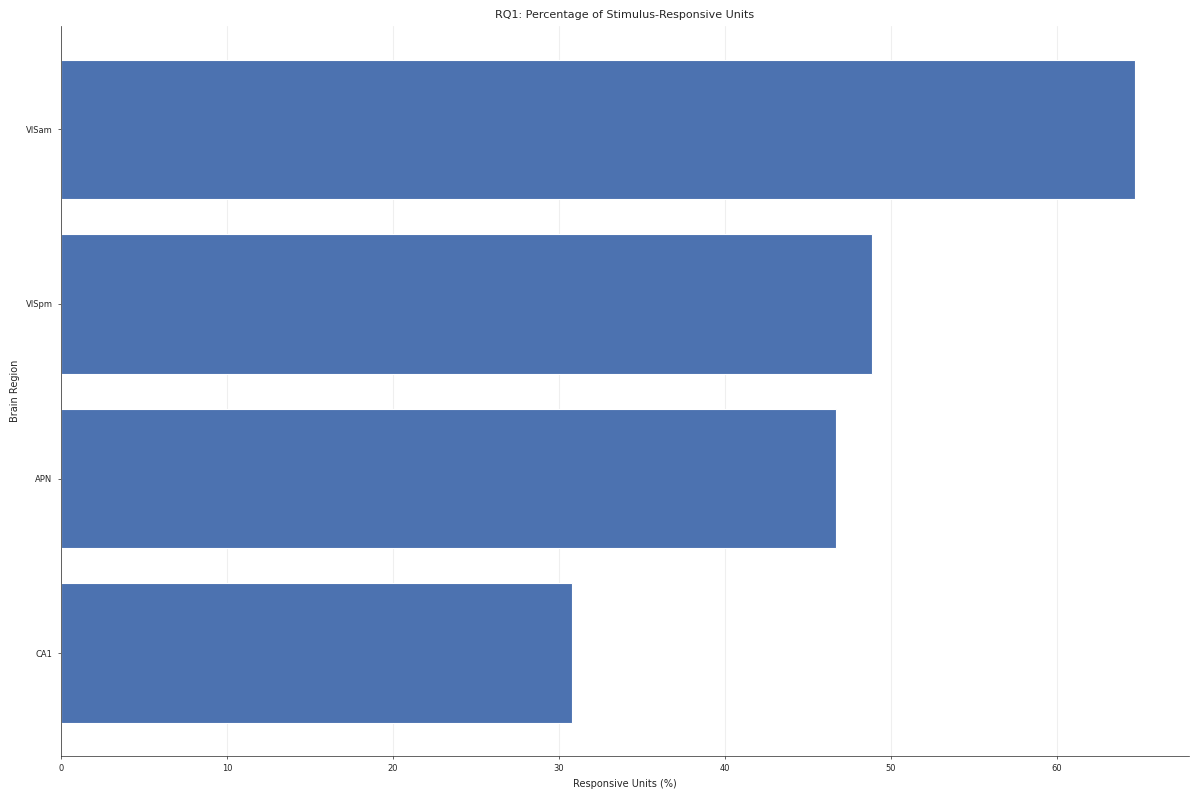

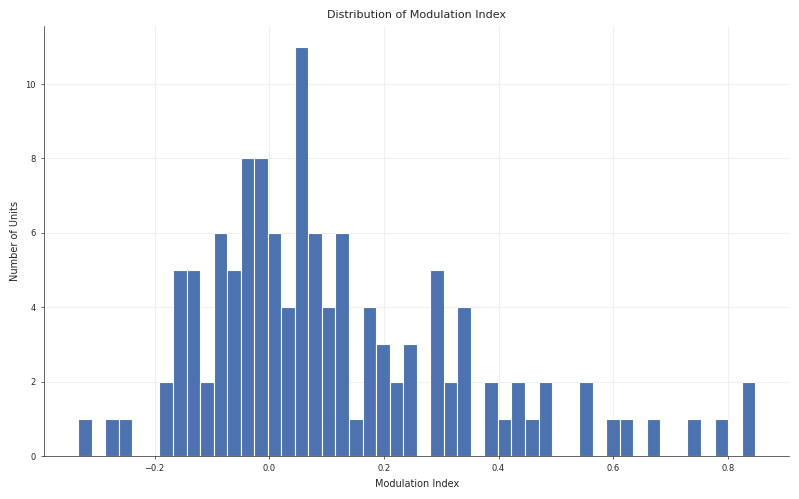

In [ ]:
# ================================================================
# RQ1:
# Which units are stimulus-responsive, and which brain regions are
# most responsive to the visual stimulus?
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# ================================================================
# 1. LOAD DATA
# ================================================================

download_data("stimOn")
meta = load_metadata("stimOn")

# Example probe insertion
pid = "0393f34c-a2bd-4c01-99c9-f6b4ec6e786d"

# Load PSTH, cluster information and trial metadata
psth, df, trials = get_psth_for_insertion(pid, meta)

# ================================================================
# 2. DEFINE TIME WINDOWS
# ================================================================

pre_window = (meta["times"] >= -0.2) & (meta["times"] < 0)

post_window = (meta["times"] >= 0) & (meta["times"] <= 0.2)

n_trials, n_clusters, _ = psth.shape

# ================================================================
# 3. CALCULATE MODULATION INDEX + WILCOXON TEST
# ================================================================

EPS = 1e-12

modulation_index = []
p_values = []

for cluster in range(n_clusters):

    baseline = psth[:, cluster, pre_window].mean(axis=1)

    response = psth[:, cluster, post_window].mean(axis=1)

    mean_baseline = baseline.mean()
    mean_response = response.mean()

    # ------------------------------
    # Modulation Index
    # ------------------------------

    mi = (mean_response - mean_baseline) / (
        mean_response + mean_baseline + EPS
    )

    modulation_index.append(mi)

    # ------------------------------
    # Wilcoxon Signed-Rank Test
    # ------------------------------

    try:

        _, p = wilcoxon(
            response,
            baseline,
            zero_method="wilcox"
        )

    except ValueError:

        p = 1.0

    p_values.append(p)

# ================================================================
# 4. STORE RESULTS
# ================================================================

df = df.copy()

df["modulation_index"] = modulation_index

df["p_value"] = p_values

# ================================================================
# 5. FDR MULTIPLE COMPARISON CORRECTION
# ================================================================

reject, p_corrected, _, _ = multipletests(
    df["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

df["corrected_p"] = p_corrected

# ================================================================
# 6. DEFINE RESPONSIVE UNITS
# ================================================================

MI_THRESHOLD = 0.10

df["is_responsive"] = (
    reject &
    (np.abs(df["modulation_index"]) >= MI_THRESHOLD)
)

# ================================================================
# 7. REMOVE UNKNOWN REGIONS
# ================================================================

df = df.dropna(subset=["acronym"])

# ================================================================
# 8. REGION-WISE SUMMARY
# ================================================================

region_stats = (

    df.groupby("acronym")

      .agg(

        total_units=("cluster_id", "count"),

        responsive_units=("is_responsive", "sum")

      )

      .reset_index()

)

region_stats["percent_responsive"] = (

    100 *

    region_stats["responsive_units"]

    /

    region_stats["total_units"]

)

# Ignore tiny regions

MIN_UNITS = 10

region_stats = region_stats[
    region_stats["total_units"] >= MIN_UNITS
]

region_stats = region_stats.sort_values(
    "percent_responsive",
    ascending=False
)

# ================================================================
# 9. DISPLAY RESULTS
# ================================================================

print("\nResponsive Units by Brain Region\n")

print(

    region_stats[
        [
            "acronym",
            "total_units",
            "responsive_units",
            "percent_responsive"
        ]
    ]

)

# ================================================================
# 10. SAVE TABLES
# ================================================================

df.to_csv("responsive_units.csv", index=False)

region_stats.to_csv("region_summary.csv", index=False)

# ================================================================
# 11. FIGURE 1
# Percentage Responsive Units
# ================================================================

top_regions = region_stats.head(20)

plt.figure(figsize=(12,8))

plt.barh(

    top_regions["acronym"],

    top_regions["percent_responsive"]

)

plt.gca().invert_yaxis()

plt.xlabel("Responsive Units (%)")

plt.ylabel("Brain Region")

plt.title("RQ1: Percentage of Stimulus-Responsive Units")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

# ================================================================
# 12. FIGURE 2
# Distribution of Modulation Index
# ================================================================

plt.figure(figsize=(8,5))

plt.hist(
    df["modulation_index"],
    bins=50
)

plt.xlabel("Modulation Index")

plt.ylabel("Number of Units")

plt.title("Distribution of Modulation Index")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## RQ2

Analyzing latency for 78 responsive units...

--- Chronological Regional Latency (Medians) ---
acronym  latency_ms
    APN        45.0
    CA1        45.0
   root        45.0
  VISam        65.0
  VISpm        65.0
    MRN        70.0
     DG       145.0


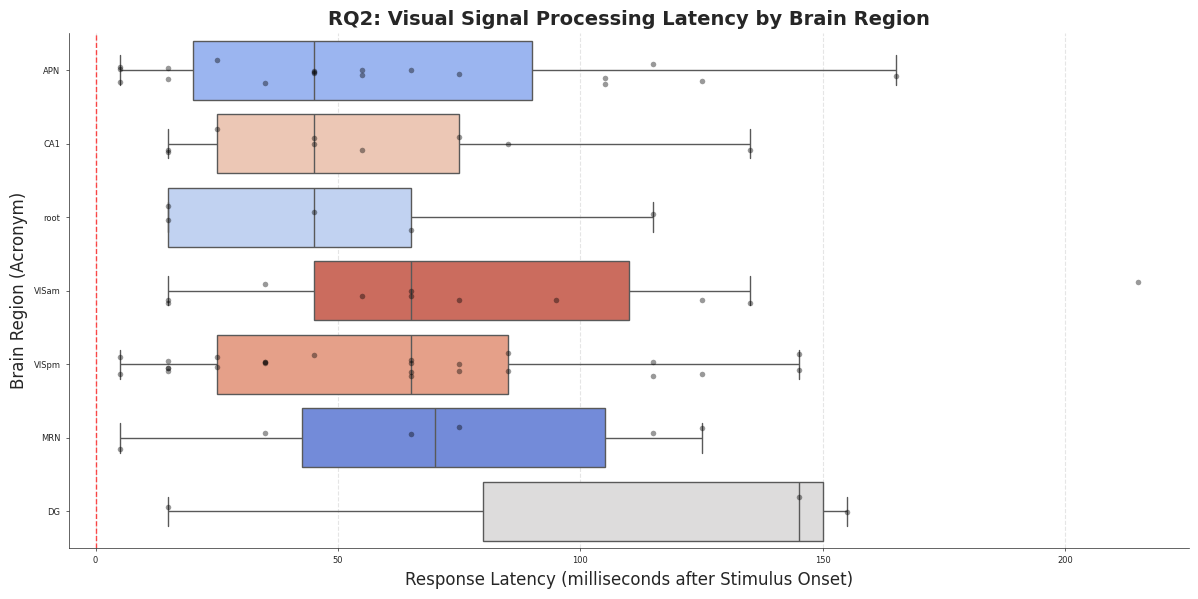

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. SETUP & FILTER RESPONSIVE UNITS ONLY
# =====================================================================
# Assumes 'df' is your cluster DataFrame and 'psth' is the matrix from RQ1.
# We slice our dataset to analyze only the units that passed the FDR correction.
responsive_df = df[df['is_responsive'] == True].copy()
responsive_indices = responsive_df.index.values

print(f"Analyzing latency for {len(responsive_indices)} responsive units...")

# Define time arrays from your metadata stream
times = meta['times']  # Array of time stamps corresponding to the PSTH bins
bin_size_ms = (times[1] - times[0]) * 1000  # Size of each bin in milliseconds

# Focus masks for the pre-stimulus baseline calculation
pre_window_idx = (times >= -0.2) & (times < 0.0)

# Identify the bin index where the stimulus actually turned on (t = 0.0)
stim_on_bin_idx = np.where(times >= 0.0)[0][0]

latencies_ms = []

# =====================================================================
# 2. COMPUTE ONSET LATENCY PER RESPONSIVE UNIT
# =====================================================================
for df_original_idx in responsive_indices:
    # Get the psth_index for the current responsive cluster from responsive_df
    # This psth_index is the correct 0-based index for the psth array's second dimension
    psth_array_idx = responsive_df.loc[df_original_idx, 'psth_index']

    # 1. Calculate the mean PSTH across all trials for this specific unit
    # Shape of single_psth becomes: (n_time_bins,)
    single_psth = psth[:, psth_array_idx, :].mean(axis=0)

    # 2. Extract baseline parameters
    baseline_vals = single_psth[pre_window_idx]
    baseline_mean = np.mean(baseline_vals)
    baseline_std = np.std(baseline_vals)

    # Avoid mathematical division or scaling errors if baseline variance is zero
    if baseline_std == 0:
        baseline_std = 1e-6

    # 3. Scan forward in time starting precisely from stimulus onset (t = 0.0)
    latency_found = False
    # Look up to 300ms post-stimulus to identify fast sensory propagation
    post_scan_bins = np.where((times >= 0.0) & (times <= 0.3))[0]

    for bin_idx in post_scan_bins:
        current_firing_rate = single_psth[bin_idx]

        # Check if the bin crosses a strict threshold of 2 standard deviations above or below baseline
        if abs(current_firing_rate - baseline_mean) > (2 * baseline_std):
            # Calculate the time delay in milliseconds relative to 0.0s
            time_at_bin = times[bin_idx]
            latency_in_ms = time_at_bin * 1000

            latencies_ms.append(latency_in_ms)
            latency_found = True
            break

    # If a unit was flagged responsive globally but didn't cross a tight 2-std window in the first 300ms
    if not latency_found:
        latencies_ms.append(np.nan)

# Save the latency data back into our filtered dataframe
responsive_df['latency_ms'] = latencies_ms

# Drop any units where a strict onset boundary wasn't located within the early scan window
responsive_df = responsive_df.dropna(subset=['latency_ms'])

# =====================================================================
# 3. GROUP BY ANATOMICAL REGION & SORT BY PROPAGATION SPEED
# =====================================================================
# Calculate the median latency for each neighborhood to map chronological flow
region_latencies = responsive_df.groupby('acronym')['latency_ms'].median().reset_index()
region_latencies = region_latencies.sort_values(by='latency_ms')

# Re-index the primary dataframe so our plot renders in chronological order
ordered_regions = region_latencies['acronym'].values

print("\n--- Chronological Regional Latency (Medians) ---")
print(region_latencies.to_string(index=False))

# =====================================================================
# 4. DELIVERABLE: VISUALIZE CHRONOLOGICAL SENSORY HIGHWAY
# =====================================================================
plt.figure(figsize=(12, 6))

# A hybrid box and strip plot shows both the median trajectory and individual cellular variance
sns.boxplot(
    data=responsive_df,
    x='latency_ms',
    y='acronym',
    order=ordered_regions,
    palette='coolwarm',
    hue='acronym',
    legend=False,
    fliersize=0
)

sns.stripplot(
    data=responsive_df,
    x='latency_ms',
    y='acronym',
    order=ordered_regions,
    color='black',
    alpha=0.4,
    size=4,
    jitter=0.2
)

plt.title('RQ2: Visual Signal Processing Latency by Brain Region', fontsize=14, fontweight='bold')
plt.xlabel('Response Latency (milliseconds after Stimulus Onset)', fontsize=12)
plt.ylabel('Brain Region (Acronym)', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Stimulus Onset (0ms)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The code block in cell fl2bLdcKMvcW is designed to calculate and visualize the onset latency of visual stimulus responses for individual neurons, and then aggregate these latencies by brain region. This helps in understanding the chronological processing of visual information across different brain areas. Here's a detailed breakdown:

Setup & Filter Responsive Units Only: This section starts by loading necessary libraries like NumPy, Pandas, Matplotlib, and Seaborn. It then filters the df DataFrame (presumably containing all clusters and their responsiveness status from a previous step, like RQ1) to include only units that have been identified as 'responsive' (where is_responsive is True) after false discovery rate (FDR) correction. This ensures that only statistically significant responses are considered.

Compute Onset Latency Per Responsive Unit: The core of this block iterates through each responsive neuron to determine its response latency. For each neuron:

It retrieves the mean PSTH (Peri-Stimulus Time Histogram) across all trials for that specific unit.
It defines a 'pre-stimulus baseline' window (-200ms to 0ms relative to stimulus onset) and calculates the mean and standard deviation of the firing rate during this period.
It then scans forward from the stimulus onset (t = 0.0s) up to 300ms post-stimulus. The latency is identified as the first time point where the neuron's firing rate deviates by more than 2 standard deviations from its baseline mean. This provides a robust measure of when a significant response begins. If no such deviation is found within the specified post-stimulus window, the latency is marked as NaN.
These calculated latencies (in milliseconds) are stored back into the responsive_df DataFrame, and any units with NaN latencies are dropped.
Group by Anatomical Region & Sort by Propagation Speed: The code then groups the responsive_df by brain region (acronym) and calculates the median latency for each region. These regions are then sorted by their median latency, allowing for an ordered view of how quickly different brain areas respond to the visual stimulus.

Visualize Chronological Sensory Highway: Finally, the results are visualized using a combination of seaborn.boxplot and seaborn.stripplot. The box plot shows the distribution of latencies within each region (median, quartiles), while the strip plot overlays individual neuron latencies as points. The regions are ordered chronologically (from fastest to slowest response), and a vertical dashed line marks the stimulus onset (0ms). This plot effectively illustrates the 'sensory highway' – the sequence in which different brain regions process the visual signal.

## RQ3

(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/Neuromatch/data_firstMove.zip: 100%|██████████| 823M/823M [00:19<00:00, 41.9MB/s]



--- Choice Decoding Leaderboard ---
Region  Neurons Count  True Accuracy  Shuffle Accuracy
   APN             30       0.803483          0.470851
 VISpm             43       0.775409          0.477302
 VISam             17       0.712997          0.442754
  root              8       0.613488          0.509724
   MRN              6       0.589598          0.425596
    DG              5       0.540042          0.505376
   CA1             13       0.535507          0.434058


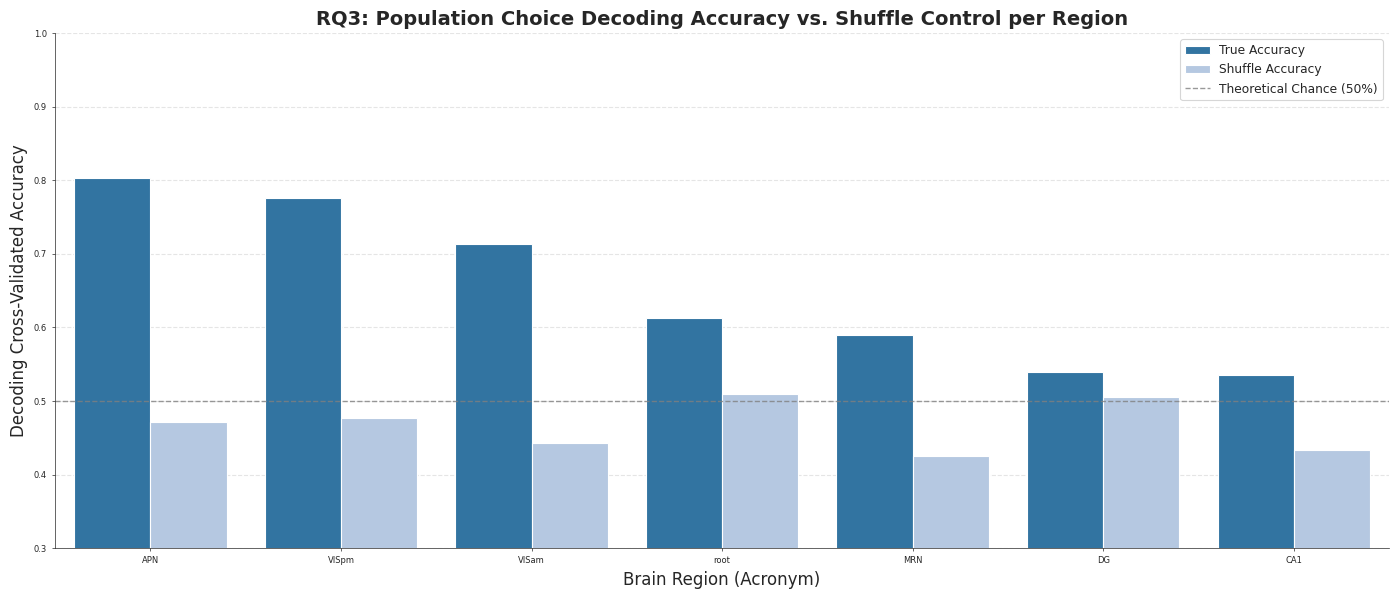

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# =====================================================================
# 1. LOAD MOVEMENT-ALIGNED DATA & METADATA
# =====================================================================
# Ensure download_data('firstMovement') has been executed in your environment
download_data('firstMove')
meta_mv = load_metadata('firstMove')

pid = "0393f34c-a2bd-4c01-99c9-f6b4ec6e786d"
psth_mv, df_mv, trials_mv = get_psth_for_insertion(pid, meta_mv)
# psth_mv shape: (n_trials, n_clusters, n_time_bins)

# Identify target labels: left vs right behavioral choices from metadata matrix
# Map choices to 0 (Left) and 1 (Right) for classification
choices = trials_mv['choice'].values
valid_idx = (choices == 1) | (choices == -1)  # Drop missed/null trials

X_all_neurons = psth_mv[valid_idx, :, :]
y = np.where(choices[valid_idx] == 1, 1, 0)   # 1 for Right, 0 for Left

# =====================================================================
# 2. ISOLATE THE PRE-MOVEMENT DECISION WINDOW
# =====================================================================
# Extract the window from -150ms to 0ms right before the wheel moves
mv_times = meta_mv['times']
pre_move_idx = (mv_times >= -0.15) & (mv_times <= 0.0)

# Average across the time window to get one scalar rate value per neuron per trial
# Shape becomes: (n_trials, n_clusters)
X_pre_move = np.mean(X_all_neurons[:, :, pre_move_idx], axis=2)

# =====================================================================
# 3. RUN PER-REGION CROSS-VALIDATION & SHUFFLE DECODING
# =====================================================================
unique_regions = df_mv['acronym'].unique()
decoding_results = []

# Minimum number of neurons required in a region to attempt population decoding
MIN_NEURONS = 5

# Set up cross-validation structure
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for region in unique_regions:
    # Get the index values of all neurons belonging to the current region
    region_neuron_indices = np.where(df_mv['acronym'].values == region)[0]

    if len(region_neuron_indices) < MIN_NEURONS:
        continue  # Skip neighborhoods with insufficient population counts

    # Isolate this specific region's population feature matrix
    X_region = X_pre_move[:, region_neuron_indices]

    # Storage vectors for performance scores
    true_accuracies = []
    shuffled_accuracies = []

    # Create a random shuffled label control baseline
    y_shuffled = np.random.permutation(y)

    for train_idx, test_idx in cv.split(X_region, y):
        X_train, X_test = X_region[train_idx], X_region[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        y_train_shuff, y_test_shuff = y_shuffled[train_idx], y_shuffled[test_idx]

        # Standardize features (highly recommended for Logistic Regression with variations in firing scales)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Initialize and fit model
        model = LogisticRegression(C=1.0, max_iter=1000, solver='liblinear')

        # Train and evaluate on true labels
        model.fit(X_train_scaled, y_train)
        true_accuracies.append(accuracy_score(y_test, model.predict(X_test_scaled)))

        # Train and evaluate on shuffled baseline labels
        model.fit(X_train_scaled, y_train_shuff)
        shuffled_accuracies.append(accuracy_score(y_test_shuff, model.predict(X_test_scaled)))

    # Document global metrics for this neighborhood
    decoding_results.append({
        'Region': region,
        'Neurons Count': len(region_neuron_indices),
        'True Accuracy': np.mean(true_accuracies),
        'Shuffle Accuracy': np.mean(shuffled_accuracies)
    })

results_df = pd.DataFrame(decoding_results)
results_df = results_df.sort_values(by='True Accuracy', ascending=False)

print("\n--- Choice Decoding Leaderboard ---")
print(results_df.to_string(index=False))

# =====================================================================
# 4. DELIVERABLE: VISUALIZE ACCURACY VS. SHUFFLE CONTROL
# =====================================================================
# Melt the DataFrame structure to make it compatible for a side-by-side seaborn plot
plot_data = pd.melt(
    results_df,
    id_vars=['Region'],
    value_vars=['True Accuracy', 'Shuffle Accuracy'],
    var_name='Condition',
    value_name='Accuracy'
)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=plot_data,
    x='Region',
    y='Accuracy',
    hue='Condition',
    palette=['#1f77b4', '#aec7e8']
)

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.8, label='Theoretical Chance (50%)')
plt.title('RQ3: Population Choice Decoding Accuracy vs. Shuffle Control per Region', fontsize=14, fontweight='bold')
plt.xlabel('Brain Region (Acronym)', fontsize=12)
plt.ylabel('Decoding Cross-Validated Accuracy', fontsize=12)
plt.ylim(0.3, 1.0)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

This code cell performs an analysis to decode a mouse's behavioral choice (left or right movement) from neural activity. It uses population-level neural activity recorded from different brain regions, specifically focusing on the time window just before the movement. Here's a breakdown of what the code does step-by-step:

1. Load Movement-Aligned Data & Metadata

First, it calls download_data('firstMove') and load_metadata('firstMove') to get data aligned to the mouse's first movement. This ensures the neural activity being analyzed is temporally relevant to the decision-making process.
It then selects a specific pid (probe insertion ID) and loads the corresponding PSTH (Peri-Stimulus Time Histogram) data, cluster metadata (df_mv), and trial metadata (trials_mv) using get_psth_for_insertion.
The mouse's choices (choices) from trials_mv are extracted and mapped to numerical labels: 1 for right choices and 0 for left choices, which will serve as the target variable (y) for classification. Invalid trials (missed or null) are filtered out.

2. Isolate the Pre-Movement Decision Window

The code defines a specific time window from -150 milliseconds to 0 milliseconds (pre_move_idx) relative to the firstMove event (which is at time 0.0s). This window is chosen to capture neural activity leading up to the decision.
For each trial and each neuron, the average firing rate within this pre-movement window is calculated, resulting in a feature matrix X_pre_move where each row is a trial and each column is a neuron's average activity in that window.

3. Run Per-Region Cross-Validation & Shuffle Decoding

The core of this section is to perform logistic regression decoding for each unique brain region identified in the selected probe insertion.
It sets a MIN_NEURONS threshold (5 neurons) for a region to be included in the analysis.
A StratifiedKFold cross-validation strategy (with 5 splits) is used to robustly evaluate the model's performance.
For each region, the code:
Extracts the neural activity data (X_region) specific to neurons within that region.
Initializes lists to store true_accuracies (for actual choice prediction) and shuffled_accuracies (as a control baseline).
It creates y_shuffled, a randomly shuffled version of the choice labels, to establish a chance-level decoding performance.
Inside the cross-validation loop:
Data is split into training and testing sets.
StandardScaler is used to standardize (normalize) the neural activity features, which is good practice for many machine learning models like Logistic Regression.
A LogisticRegression model is trained and evaluated on both the true choice labels and the shuffled labels.
The average true and shuffled accuracies for each region are stored in decoding_results, which is then converted into a DataFrame (results_df) and sorted by true accuracy.

4. Visualize Accuracy vs. Shuffle Control

Finally, the results_df is reshaped (pd.melt) to be suitable for plotting.
seaborn.barplot is used to visualize the decoding accuracy for each brain region. It displays two bars per region: one for the 'True Accuracy' (how well the model predicted actual choices) and one for 'Shuffle Accuracy' (how well it predicted random choices).
A horizontal dashed line is added at 0.5 (50%), representing theoretical chance level for a binary classification task.
This visualization helps to identify which brain regions contain neural populations that encode information about the mouse's upcoming choice significantly better than chance.

## RQ-Bonus


--- Pre-Stimulus Block Prior Decoding Leaderboard ---
Region  Neurons Count  True Accuracy  Shuffle Accuracy
   APN             30       0.599304          0.571677
 VISpm             43       0.581614          0.509082
 VISam             17       0.574494          0.478734
   CA1             13       0.574114          0.496297
    DG              5       0.546614          0.536329
   MRN              6       0.539146          0.566614
  root              8       0.534051          0.554051


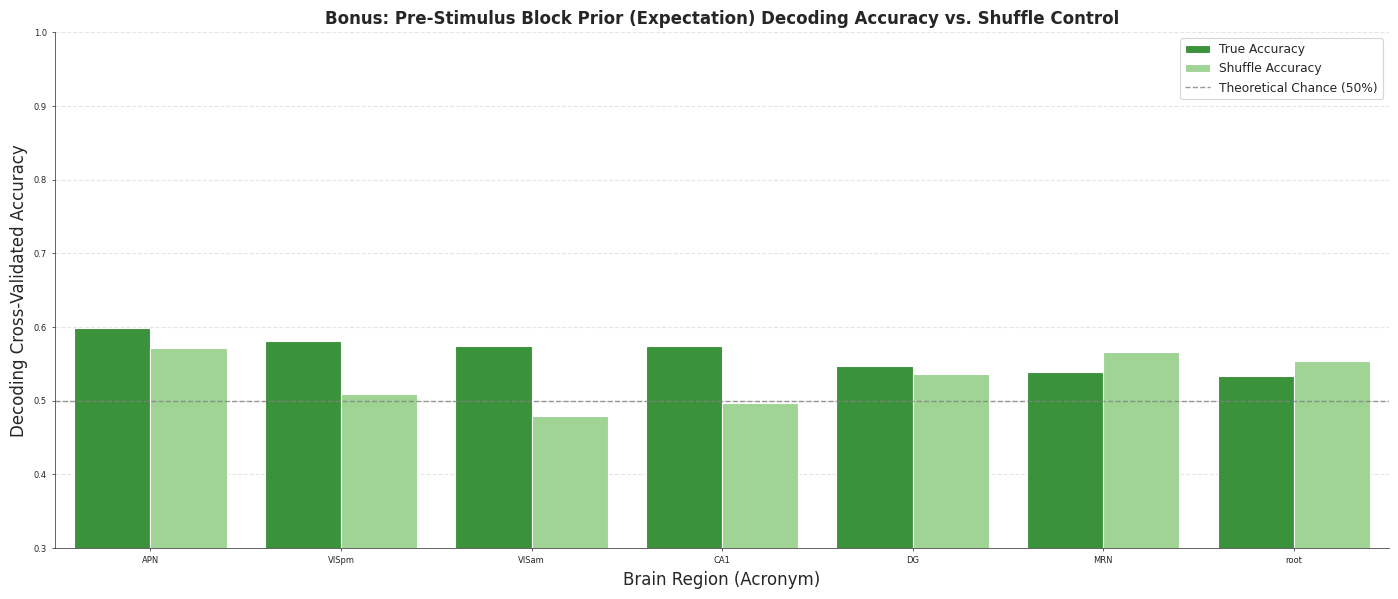

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# =====================================================================
# 1. LOAD STIMULUS-ALIGNED DATA & BLOCK METADATA
# =====================================================================
# We use the 'stimOn' data because we want to inspect the quiet period BEFORE the stimulus hits
download_data('stimOn')
meta_stim = load_metadata('stimOn')

pid = "0393f34c-a2bd-4c01-99c9-f6b4ec6e786d"
psth_stim, df_stim, trials_stim = get_psth_for_insertion(pid, meta_stim)
# psth_stim shape: (n_trials, n_clusters, n_time_bins)

# Identify target labels: The objective block prior probability structure
# In the IBL task, trials_stim['probabilityLeft'] usually holds values like 0.2 (Right Block) or 0.8 (Left Block)
block_prior = trials_stim['probabilityLeft'].values

# Filter out any unassigned or non-standard trials (e.g., 0.5 unbiased block trials if present)
valid_block_idx = (block_prior == 0.8) | (block_prior == 0.2)

X_all_trials = psth_stim[valid_block_idx, :, :]
# Class labels: 1 if Left-biased Block (0.8), 0 if Right-biased Block (0.2)
y_block = np.where(block_prior[valid_block_idx] == 0.8, 1, 0)

# =====================================================================
# 2. ISOLATE THE PRE-STIMULUS COGNITIVE WINDOW
# =====================================================================
# Extract the window from -400ms to -50ms before the image turns on
stim_times = meta_stim['times']
pre_stim_idx = (stim_times >= -0.4) & (stim_times <= -0.05)

# Collapse time to calculate the scalar mean resting firing rate per neuron per trial
# Shape becomes: (n_trials, n_clusters)
X_expectation = np.mean(X_all_trials[:, :, pre_stim_idx], axis=2)

# =====================================================================
# 3. RUN POPULATION EXPECTATION DECODER & SHUFFLE BASELINE
# =====================================================================
unique_regions = df_stim['acronym'].unique()
block_decoding_results = []

MIN_NEURONS = 5
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for region in unique_regions:
    # Gather structural indexes for cells in this region
    region_neuron_indices = np.where(df_stim['acronym'].values == region)[0]

    if len(region_neuron_indices) < MIN_NEURONS:
        continue

    X_region = X_expectation[:, region_neuron_indices]

    true_accuracies = []
    shuffled_accuracies = []

    # Generate a target-shuffled array to establish our noise baseline
    y_shuffled = np.random.permutation(y_block)

    for train_idx, test_idx in cv.split(X_region, y_block):
        X_train, X_test = X_region[train_idx], X_region[test_idx]
        y_train, y_test = y_block[train_idx], y_block[test_idx]
        y_train_shuff, y_test_shuff = y_shuffled[train_idx], y_shuffled[test_idx]

        # Scale input features to standard normal distributions
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Logistic Regression with mild L2 regularization to manage multi-collinearity
        model = LogisticRegression(C=0.5, max_iter=1000, solver='liblinear')

        # Decode the True Block Expectation state
        model.fit(X_train_scaled, y_train)
        true_accuracies.append(accuracy_score(y_test, model.predict(X_test_scaled)))

        # Decode the Shuffled Baseline Control
        model.fit(X_train_scaled, y_train_shuff)
        shuffled_accuracies.append(accuracy_score(y_test_shuff, model.predict(X_test_scaled)))

    block_decoding_results.append({
        'Region': region,
        'Neurons Count': len(region_neuron_indices),
        'True Accuracy': np.mean(true_accuracies),
        'Shuffle Accuracy': np.mean(shuffled_accuracies)
    })

block_results_df = pd.DataFrame(block_decoding_results)
block_results_df = block_results_df.sort_values(by='True Accuracy', ascending=False)

print("\n--- Pre-Stimulus Block Prior Decoding Leaderboard ---")
print(block_results_df.to_string(index=False))

# =====================================================================
# 4. DELIVERABLE: VISUALIZE HIDDEN EXPECTATION MAP
# =====================================================================
# Restructure for visualization syntax
plot_data_bonus = pd.melt(
    block_results_df,
    id_vars=['Region'],
    value_vars=['True Accuracy', 'Shuffle Accuracy'],
    var_name='Condition',
    value_name='Accuracy'
)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=plot_data_bonus,
    x='Region',
    y='Accuracy',
    hue='Condition',
    palette=['#2ca02c', '#98df8a'] # Green theme to differentiate from choice decoding
)

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.8, label='Theoretical Chance (50%)')
plt.title('Bonus: Pre-Stimulus Block Prior (Expectation) Decoding Accuracy vs. Shuffle Control', fontsize=12, fontweight='bold')
plt.xlabel('Brain Region (Acronym)', fontsize=12)
plt.ylabel('Decoding Cross-Validated Accuracy', fontsize=12)
plt.ylim(0.3, 1.0)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

This code block performs an advanced analysis to determine if a mouse's expectation about the 'block prior' (the likelihood of a stimulus appearing on the left or right) can be decoded from its neural activity before the stimulus even appears. This is a fascinating cognitive decoding task. Here's a breakdown:

1. Setup and Data Loading:

It starts by importing necessary libraries like NumPy for numerical operations, Pandas for data manipulation, Matplotlib and Seaborn for plotting, and scikit-learn for machine learning tasks (Logistic Regression, cross-validation, and data scaling).
It downloads and loads data aligned to stimOn (stimulus onset) because the goal is to look at neural activity before the stimulus appears.
A specific pid (probe insertion ID) is chosen for analysis.
The trials_stim['probabilityLeft'] column, which indicates the objective block structure (e.g., 0.8 for left-biased blocks, 0.2 for right-biased blocks), is used to define the block_prior.
Trials with these specific block probabilities (0.8 or 0.2) are filtered using valid_block_idx.
The y_block variable is created as the target for decoding: 1 for left-biased blocks (0.8 probabilityLeft) and 0 for right-biased blocks (0.2 probabilityLeft). This binary labeling is suitable for binary classification.

2. Isolating the Pre-Stimulus Cognitive Window:

It defines pre_stim_idx to select a specific time window: from -400 milliseconds to -50 milliseconds before stimulus onset (which is at 0.0s). This window aims to capture neural activity reflecting the mouse's internal expectation or 'prior' before any sensory input about the current trial's stimulus.
X_expectation is computed by taking the mean neural firing rate for each neuron in each trial within this pre_stim_idx time window. This collapses the time dimension, resulting in a feature matrix where each row is a trial and each column represents the average activity of a neuron during that pre-stimulus period.

3. Running Population Expectation Decoder & Shuffle Baseline:

The code iterates through each unique brain region recorded in the selected probe insertion.
For each region, it checks if there are at least MIN_NEURONS (set to 5) to ensure sufficient data for decoding.
X_region isolates the neural activity features only for neurons belonging to the current region.
StratifiedKFold is used to split the data into training and testing sets, ensuring that the proportion of y_block classes (left vs. right biased blocks) is maintained in each fold. This helps in getting a robust estimate of decoding accuracy.
A y_shuffled array is created by randomly permuting the y_block labels. This serves as a critical baseline to assess whether the decoder performs significantly better than chance (i.e., whether it's actually picking up on meaningful neural signals related to the block prior, or just noise).
Inside the cross-validation loop:
Data (X_train, X_test, y_train, y_test) is prepared.
StandardScaler is applied to normalize the neural activity features. This is important for many machine learning algorithms, including Logistic Regression, to prevent features with larger scales from dominating the model.
A LogisticRegression model is initialized and trained. It uses C=0.5 for mild L2 regularization to prevent overfitting and solver='liblinear' for efficiency with smaller datasets.
The model is trained and evaluated twice: once on the true_accuracies (actual block labels) and once on shuffled_accuracies (randomized block labels).
The mean true and shuffled accuracies, along with the region name and neuron count, are stored in block_decoding_results.

4. Visualization of Hidden Expectation Map:

The block_decoding_results are converted into a Pandas DataFrame (block_results_df) and sorted by 'True Accuracy'.
The DataFrame is then 'melted' to restructure it, making it suitable for plotting with Seaborn.
seaborn.barplot is used to create a bar chart, visually comparing the 'True Accuracy' (dark green bars) against the 'Shuffle Accuracy' (light green bars) for each brain region. This helps to identify regions where neural activity significantly predicts the block prior.
A horizontal dashed line at 0.5 (50%) represents the theoretical chance level for a binary classification task. Any 'True Accuracy' bars significantly above the corresponding 'Shuffle Accuracy' and the 50% line suggest that the region's neural activity encodes information about the block prior.